# Climatic data exploration

This notebook explores the climatic data used in the project. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Load data

In [2]:
periods = ['1940-1970', '1994-2024', '2021-2050']
scenarios = ['ssp126', 'ssp370', 'ssp585']

datasets = {}

for period in periods:
    if period == '2021-2050':
        for scenario in scenarios:
            key = f"{period}_{scenario}"
            datasets[key] = pd.read_csv(f"datasets/climate_features_{period}_{scenario}.csv")
    else:
        datasets[period] = pd.read_csv(f"datasets/climate_features_{period}.csv")

In [3]:
print("Loaded datasets:")

for key, df in datasets.items():
    print(f"Dataset: {key}")

Loaded datasets:
Dataset: 1940-1970
Dataset: 1994-2024
Dataset: 2021-2050_ssp126
Dataset: 2021-2050_ssp370
Dataset: 2021-2050_ssp585


## Features distribution

In [4]:
def summarize_dataset(df):
    print("First 5 rows:")
    print(df.head())
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values per column:")
    print(df.isnull().sum())
    print("\nStatistical summary:")
    print(df.describe())

def format_value(val):
    """Format value with at least 2 significant digits"""
    if abs(val) >= 100:
        return f"{val:.2f}"
    elif abs(val) >= 10:
        return f"{val:.3f}"
    elif abs(val) >= 1:
        return f"{val:.3f}"
    elif abs(val) >= 0.01:
        return f"{val:.4f}"
    else:
        return f"{val:.3g}"

def plot_feature_distributions(df, features):
    # Filtrer les colonnes de latitude et longitude
    features_filtered = [f for f in features if f.lower() not in ['latitude', 'longitude', 'lat', 'lon']]
    
    for feature in features_filtered:
        # Créer une figure pour une seule feature
        fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
        
        # Histogram
        axes[0].hist(df[feature].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0].set_title(f'{feature}', fontsize=9, fontweight='bold')
        axes[0].set_ylabel('Fréquence', fontsize=8)
        axes[0].tick_params(labelsize=7)
        axes[0].grid(True, alpha=0.3)
        
        # Boxplot
        bp = axes[1].boxplot(df[feature].dropna(), vert=True, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        
        # Calculer les statistiques
        data = df[feature].dropna()
        stats_text = f"Min: {format_value(data.min())}\nQ1: {format_value(data.quantile(0.25))}\nMed: {format_value(data.median())}\nQ3: {format_value(data.quantile(0.75))}\nMax: {format_value(data.max())}"
        
        axes[1].text(1.15, data.median(), stats_text, va='center', fontsize=7)
        axes[1].set_title('Boxplot', fontsize=9)
        axes[1].tick_params(labelsize=7)
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].set_xticklabels([])
        
        plt.tight_layout()
        plt.show()
        
        # Identifier et afficher les outliers
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers_mask = (df[feature] < lower_bound) | (df[feature] > upper_bound)
        
        if 'city' in df.columns:
            outliers_df = df[outliers_mask][['city', feature]].sort_values(by=feature)
            
            if not outliers_df.empty:
                print(f"Outliers for {feature} ({len(outliers_df)} cities):")
                cities_list = [f"{row_data['city']} ({format_value(row_data[feature])})" for _, row_data in outliers_df.iterrows()]
                print(", ".join(cities_list))
                print()
            else:
                print(f"No outliers for {feature}\n")



--- Summary for dataset: 1940-1970 ---

First 5 rows:
                city   latitude  longitude  sf_winter     sf_spring  \
0             Aachen  50.776642    6.08342   0.000601  3.923203e-05   
1           Aberdeen  57.143688   -2.09814   0.000442  3.259413e-05   
2    Aix-en-Provence  43.528301    5.44973   0.000121  7.028648e-07   
3  Alcalá de Henares  40.482052   -3.35996   0.000210  6.236482e-06   
4           Alicante  38.345169   -0.48149   0.000052  7.485617e-06   

      sf_summer  sf_autumn  t2m_winter  t2m_spring  t2m_summer  ...  \
0  6.409102e-09   0.000255   274.22504   281.47950   289.19217  ...   
1  0.000000e+00   0.000086   277.16890   279.73547   285.77548  ...   
2  0.000000e+00   0.000039   278.54050   285.54474   294.89127  ...   
3  0.000000e+00   0.000082   277.32727   284.38162   295.33160  ...   
4  0.000000e+00   0.000017   282.93810   287.88943   296.55975  ...   

   min_t2m_spring  temp_range_spring  max_t2m_summer  min_t2m_summer  \
0       277.51660  

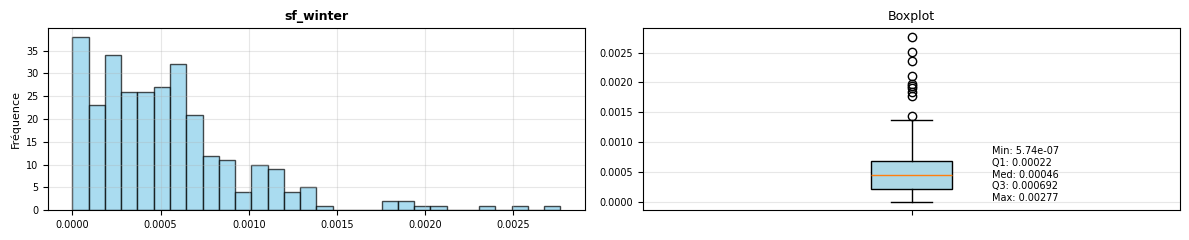

Outliers for sf_winter (10 cities):
Reykjavík (0.00144), Zürich (0.00177), Sochi (0.00183), Lausanne (0.0019), Grenoble (0.00193), Sarajevo (0.00198), Bern (0.0021), Bergen (0.00236), Salzburg (0.00252), Innsbruck (0.00277)



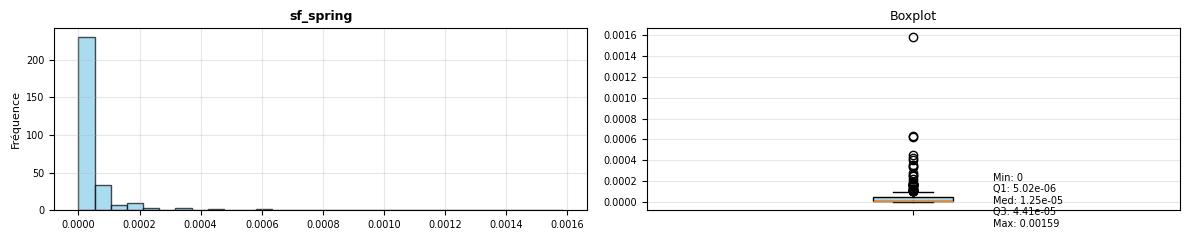

Outliers for sf_spring (34 cities):
Vilnius (0.000103), Freiburg (0.000104), Basel (0.000105), Stockholm (0.000105), Sochi (0.000105), Riga (0.000108), Sofia (0.000111), Bergamo (0.000124), Tallinn (0.000128), Moscow (0.000128), Turku (0.000146), Helsinki (0.000158), Ljubljana (0.000159), Saint Petersburg (0.000165), Vantaa (0.000165), Yaroslavl' (0.000167), Graz (0.000172), Espoo (0.000174), München (0.000174), Braşov (0.000175), Como (0.000196), Tampere (0.000219), Sarajevo (0.000247), Oslo (0.000258), Oulu (0.000276), Grenoble (0.000334), Lausanne (0.000341), Reykjavík (0.000351), Turin (0.000401), Bergen (0.000426), Zürich (0.000455), Bern (0.000625), Salzburg (0.000631), Innsbruck (0.00159)



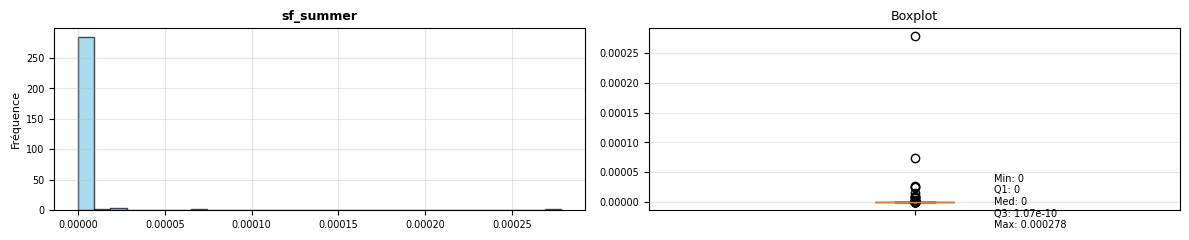

Outliers for sf_summer (73 cities):
Salamanca (4.27e-10), Madrid (4.27e-10), Kassel (4.27e-10), Erfurt (5.7e-10), Köln (9.61e-10), Clermont-Ferrand (1.28e-09), Burgos (1.92e-09), Maastricht (1.92e-09), Mulhouse (2.56e-09), Liège (2.56e-09), Stuttgart (2.99e-09), Pamplona (3.53e-09), Augsburg (3.69e-09), Milan (4.27e-09), Dresden (4.27e-09), Basel (4.49e-09), Brno (4.65e-09), Ostrava (4.7e-09), Hagen (4.7e-09), Dortmund (6.27e-09), Aachen (6.41e-09), Göteborg (6.84e-09), Kraków (9.45e-09), Verona (1.07e-08), Besançon (1.14e-08), Freiburg (1.28e-08), Plzeň (1.45e-08), Zagreb (2.05e-08), Gijón (2.44e-08), Saint-Étienne (3.01e-08), Riga (5.06e-08), Tirana (5.61e-08), Trieste (7.01e-08), Chemnitz (1.06e-07), Stockholm (1.26e-07), Perpignan (1.26e-07), Tallinn (2.23e-07), Ploieşti (2.69e-07), Cluj-Napoca (2.71e-07), Skopje (2.83e-07), Helsinki (4.59e-07), Moscow (4.6e-07), Nice (5.01e-07), Turku (5.25e-07), Vantaa (5.26e-07), Espoo (5.99e-07), München (6.16e-07), Kiev (7.76e-07), Brescia (9.

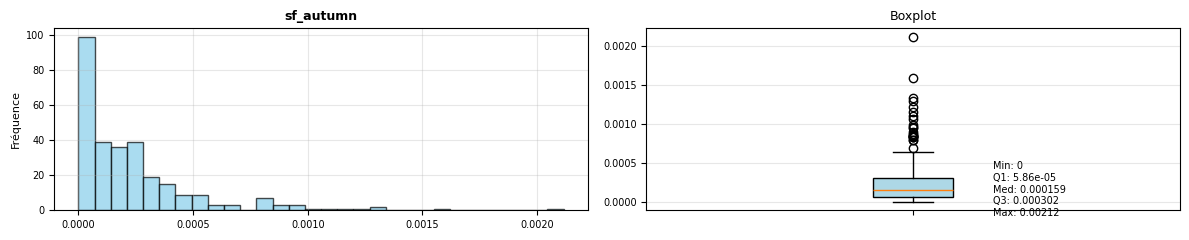

Outliers for sf_autumn (22 cities):
München (0.000689), Helsinki (0.000791), Graz (0.000792), Turin (0.000831), Vantaa (0.000831), Saint Petersburg (0.000835), Moscow (0.000839), Espoo (0.00084), Tampere (0.00086), Ljubljana (0.000866), Oulu (0.000893), Yaroslavl' (0.000949), Sarajevo (0.000961), Reykjavík (0.000986), Zürich (0.00106), Lausanne (0.0011), Oslo (0.00116), Grenoble (0.00121), Bergen (0.00129), Bern (0.00133), Salzburg (0.00158), Innsbruck (0.00212)



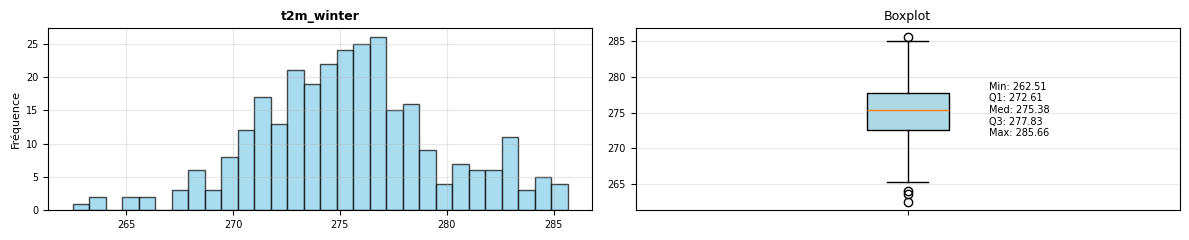

Outliers for t2m_winter (4 cities):
Yaroslavl' (262.51), Moscow (263.57), Oulu (263.99), Marsala (285.66)



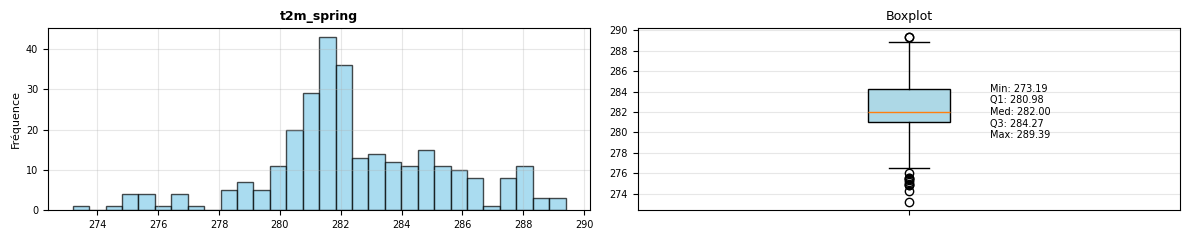

Outliers for t2m_spring (13 cities):
Oulu (273.19), Innsbruck (274.30), Tampere (274.85), Helsinki (274.88), Espoo (274.91), Vantaa (275.13), Saint Petersburg (275.39), Tallinn (275.46), Reykjavík (275.52), Turku (275.56), Yaroslavl' (276.03), Jerez de la Frontera (289.36), Sevilla (289.39)



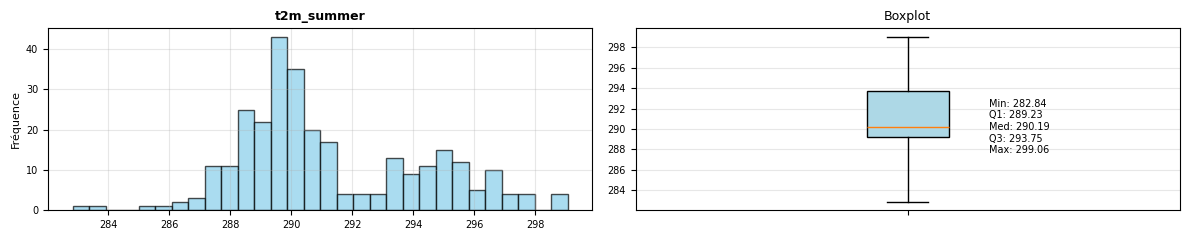

No outliers for t2m_summer



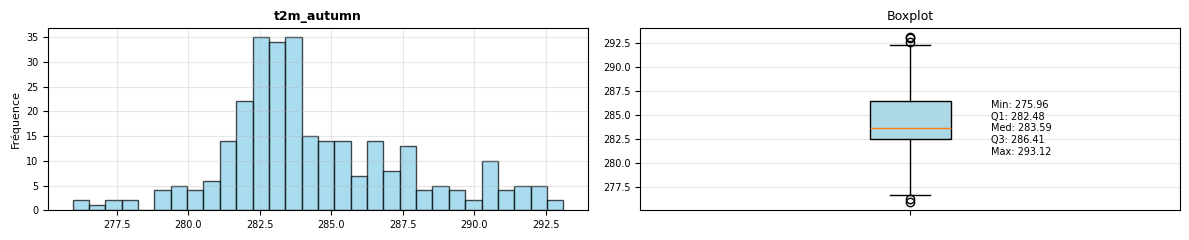

Outliers for t2m_autumn (5 cities):
Innsbruck (275.96), Oulu (276.24), Palma (292.53), Siracusa (292.96), Marsala (293.12)



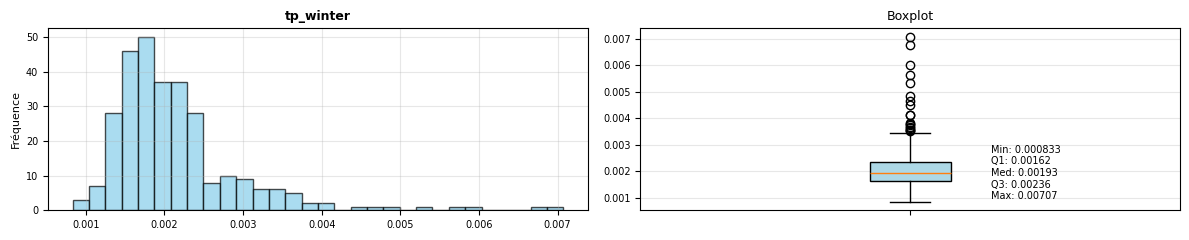

Outliers for tp_winter (18 cities):
Grenoble (0.00353), Lausanne (0.00355), Donostia / San Sebastián (0.00357), Oviedo (0.00362), Split (0.00368), Gijón (0.00373), Napoli (0.00378), La Spezia (0.00382), Salerno (0.0041), Reykjavík (0.00413), Tirana (0.0045), Sochi (0.00463), Coimbra (0.00485), Santiago de Compostela (0.00534), Bergen (0.00563), Porto (0.00601), Braga (0.00676), Vigo (0.00707)



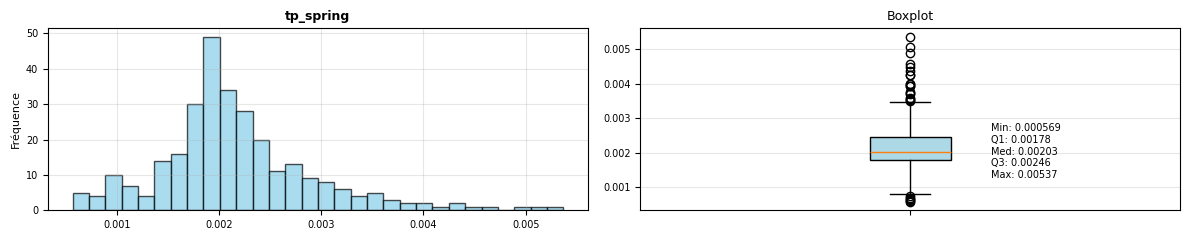

Outliers for tp_spring (25 cities):
Siracusa (0.000569), Piraeus (0.000601), Cartagena (0.000621), Marsala (0.000654), Athens (0.000696), Palma (0.000737), Braga (0.00349), Verona (0.00353), Basel (0.00357), Sarajevo (0.00358), Trieste (0.0037), Brescia (0.00373), Grenoble (0.00375), Ljubljana (0.00393), München (0.00393), Milan (0.00399), Lausanne (0.00401), Turin (0.00424), Bern (0.00426), Zürich (0.00438), Bergamo (0.0045), Bergen (0.00457), Como (0.00491), Innsbruck (0.00506), Salzburg (0.00537)



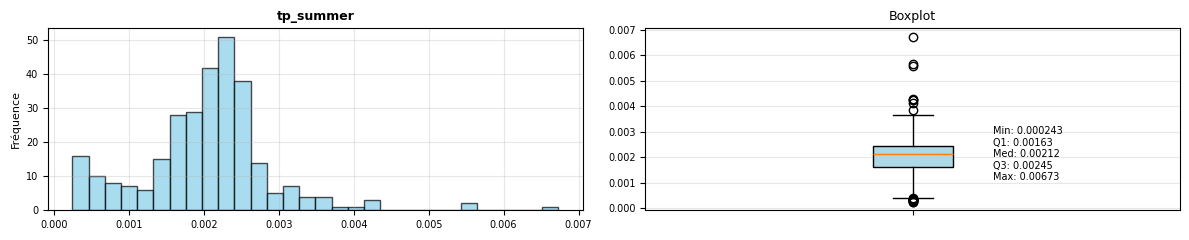

Outliers for tp_summer (21 cities):
Piraeus (0.000243), Roquetas de Mar (0.000246), Athens (0.000268), Málaga (0.000287), Cartagena (0.000308), Jerez de la Frontera (0.000317), Córdoba (0.000318), Sevilla (0.000318), Marbella (0.000332), Setúbal (0.000344), Almería (0.000349), Lisbon (0.000359), Murcia (0.000394), Bergamo (0.00386), Lausanne (0.00413), Como (0.00424), Zürich (0.00425), Bern (0.00429), Salzburg (0.00558), Innsbruck (0.00565), Bergen (0.00673)



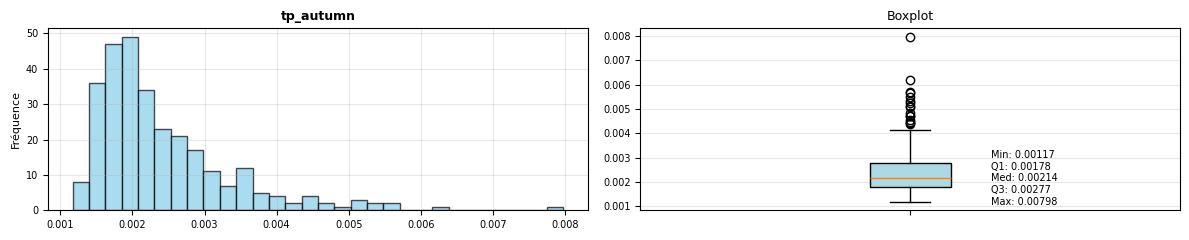

Outliers for tp_autumn (16 cities):
Donostia / San Sebastián (0.00437), Lucca (0.00441), Rome (0.00445), Pisa (0.00456), Santiago de Compostela (0.0047), Reykjavík (0.00472), Trieste (0.00482), Tirana (0.00507), La Spezia (0.00512), Porto (0.00525), Split (0.00533), Napoli (0.00548), Braga (0.00567), Salerno (0.0057), Vigo (0.00621), Bergen (0.00798)



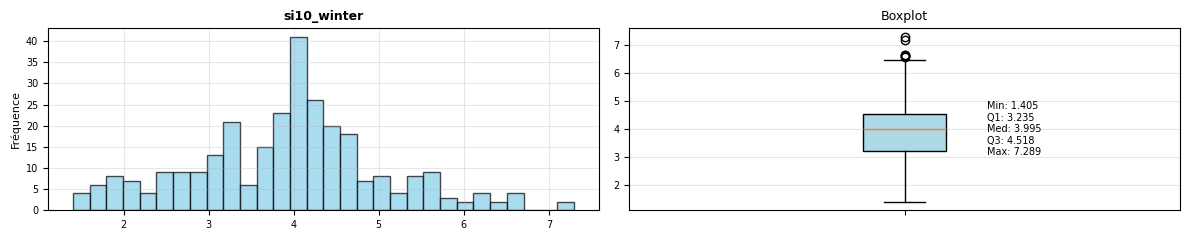

Outliers for si10_winter (6 cities):
The Hague (6.554), Marsala (6.585), Blackpool (6.640), Aberdeen (6.649), Eastbourne (7.162), Brest (7.289)



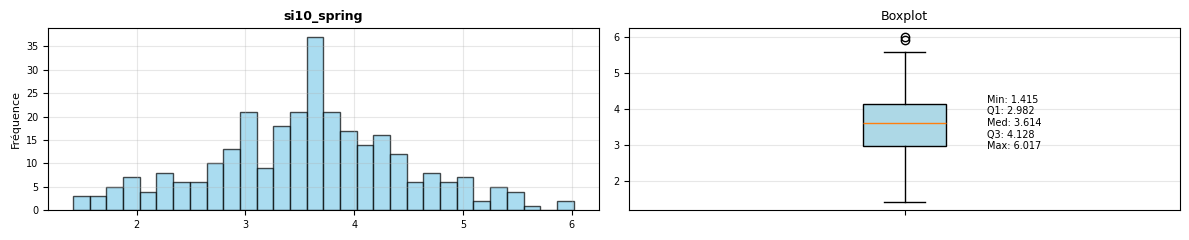

Outliers for si10_spring (2 cities):
Eastbourne (5.919), Brest (6.017)



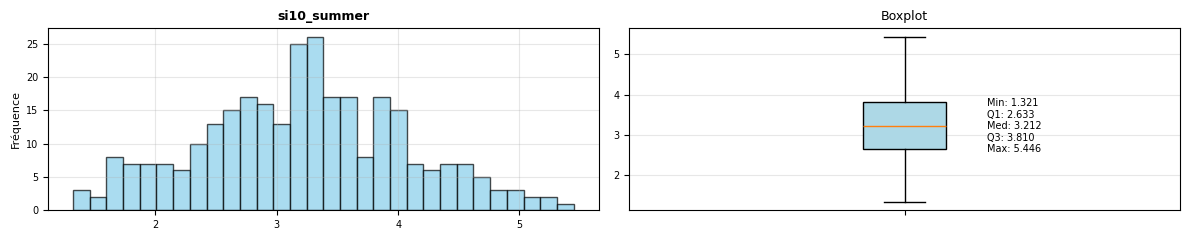

No outliers for si10_summer



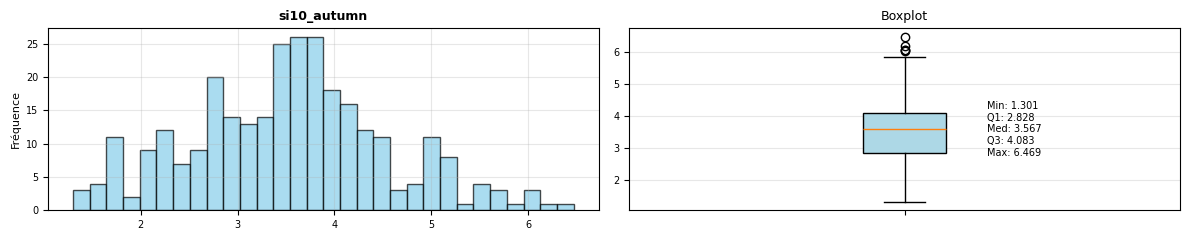

Outliers for si10_autumn (5 cities):
The Hague (6.021), Aberdeen (6.038), Brest (6.053), Blackpool (6.185), Eastbourne (6.469)



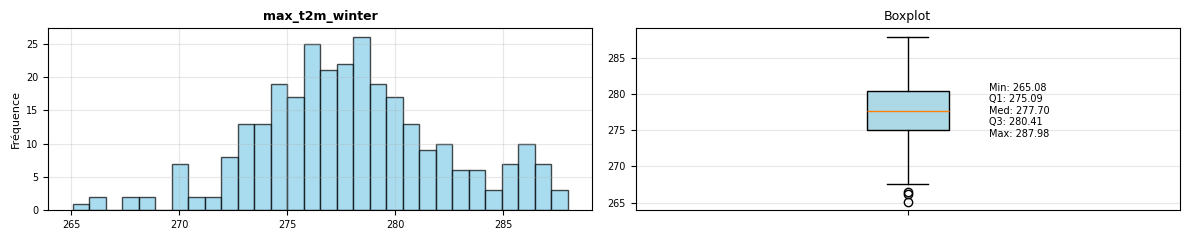

Outliers for max_t2m_winter (3 cities):
Yaroslavl' (265.08), Moscow (266.20), Oulu (266.48)



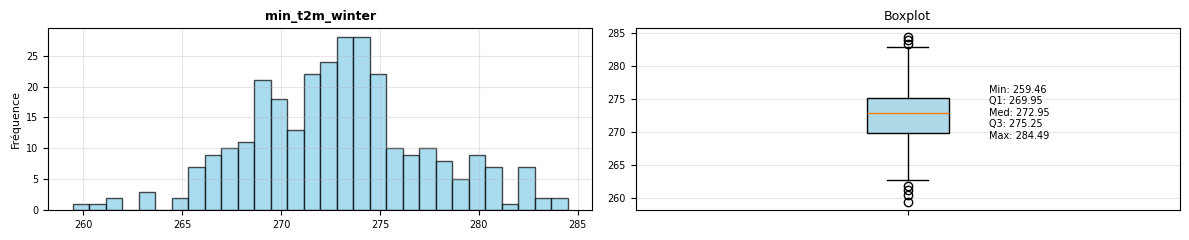

Outliers for min_t2m_winter (7 cities):
Yaroslavl' (259.46), Moscow (260.51), Oulu (261.34), Innsbruck (261.87), Siracusa (283.35), Palma (284.00), Marsala (284.49)



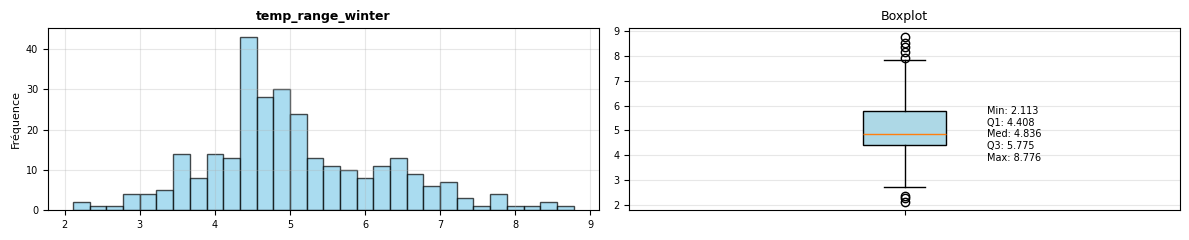

Outliers for temp_range_winter (8 cities):
Palma (2.113), Brest (2.265), Marsala (2.339), Elche (7.911), Sofia (8.159), Sevilla (8.338), Córdoba (8.515), Murcia (8.776)



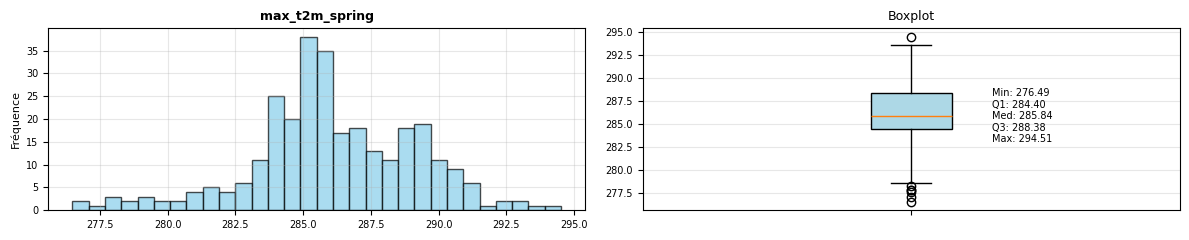

Outliers for max_t2m_spring (7 cities):
Oulu (276.49), Helsinki (277.04), Espoo (277.58), Vantaa (277.76), Reykjavík (277.82), Tallinn (278.21), Sevilla (294.51)



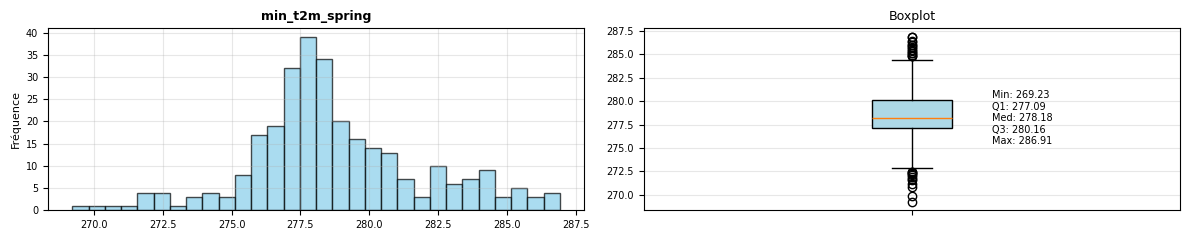

Outliers for min_t2m_spring (27 cities):
Oulu (269.23), Innsbruck (269.91), Tampere (270.84), Saint Petersburg (271.16), Yaroslavl' (271.59), Turku (271.74), Espoo (271.87), Vantaa (272.13), Tallinn (272.26), Helsinki (272.36), Moscow (272.38), Oslo (272.44), Bari (284.79), Taranto (284.84), Palermo (284.95), Piraeus (285.14), Setúbal (285.16), Lisbon (285.35), Marbella (285.48), Roquetas de Mar (285.69), Messina (285.83), Jerez de la Frontera (286.02), Lecce (286.06), Siracusa (286.36), Cartagena (286.39), Marsala (286.89), Palma (286.91)



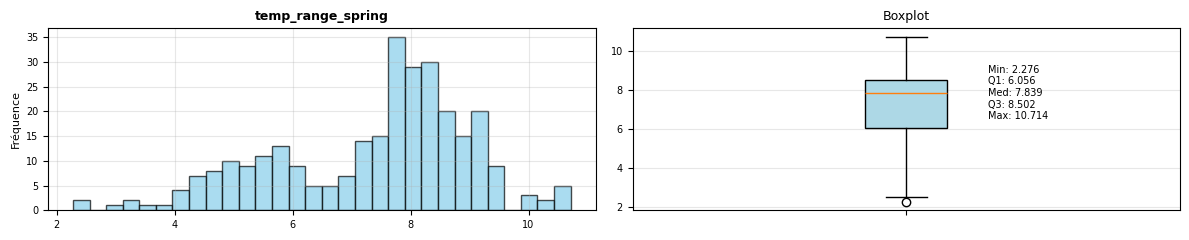

Outliers for temp_range_spring (1 cities):
Brest (2.276)



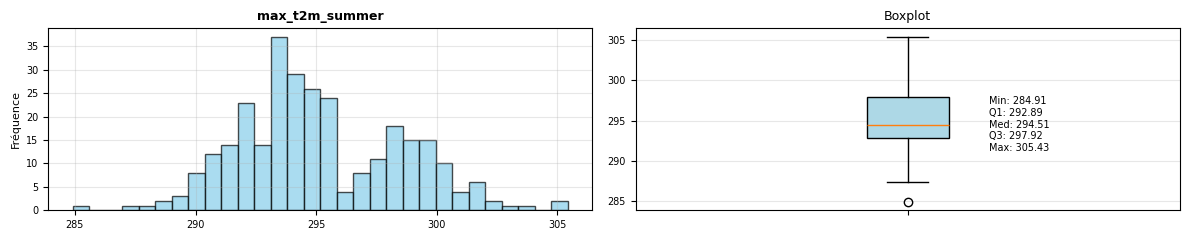

Outliers for max_t2m_summer (1 cities):
Reykjavík (284.91)



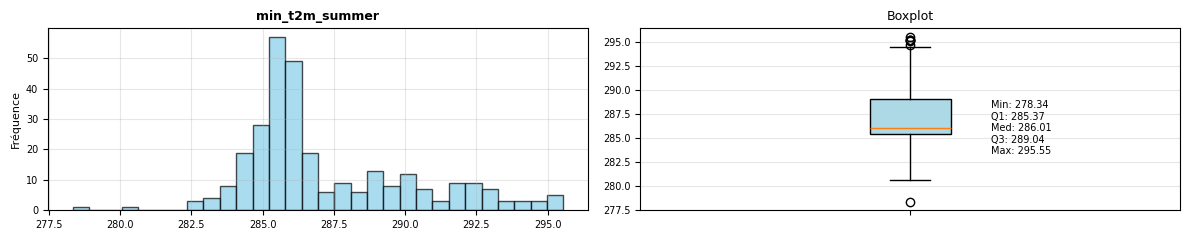

Outliers for min_t2m_summer (7 cities):
Innsbruck (278.34), Messina (294.70), Piraeus (295.06), Palma (295.15), Marsala (295.16), Lecce (295.19), Siracusa (295.55)



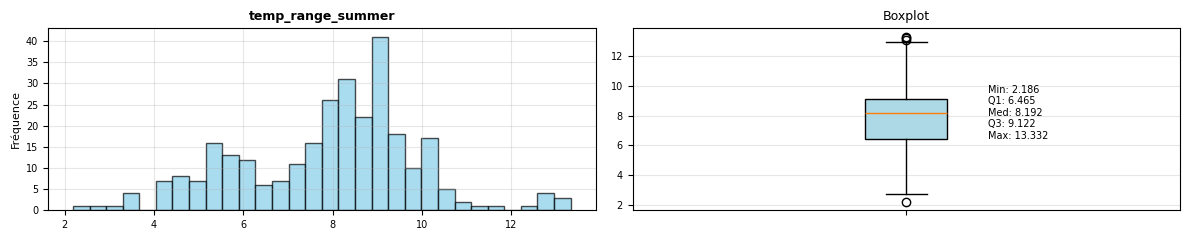

Outliers for temp_range_summer (4 cities):
Brest (2.186), Alcalá de Henares (13.115), Córdoba (13.270), Valladolid (13.332)



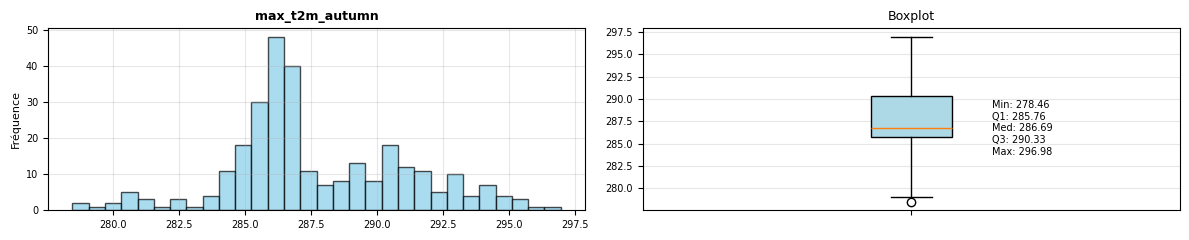

Outliers for max_t2m_autumn (1 cities):
Oulu (278.46)



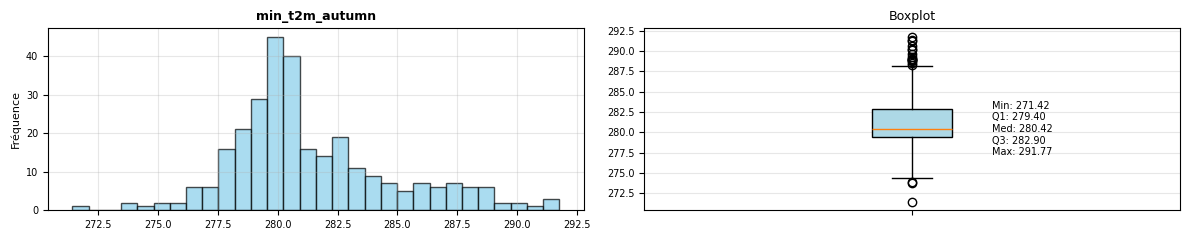

Outliers for min_t2m_autumn (18 cities):
Innsbruck (271.42), Oulu (273.78), Yaroslavl' (273.85), Athens (288.24), Marbella (288.57), Bari (288.75), Catania (288.87), Jerez de la Frontera (288.94), Roquetas de Mar (288.98), Taranto (289.05), Piraeus (289.24), Palermo (289.63), Cartagena (290.10), Lecce (290.25), Messina (290.57), Siracusa (291.20), Palma (291.40), Marsala (291.77)



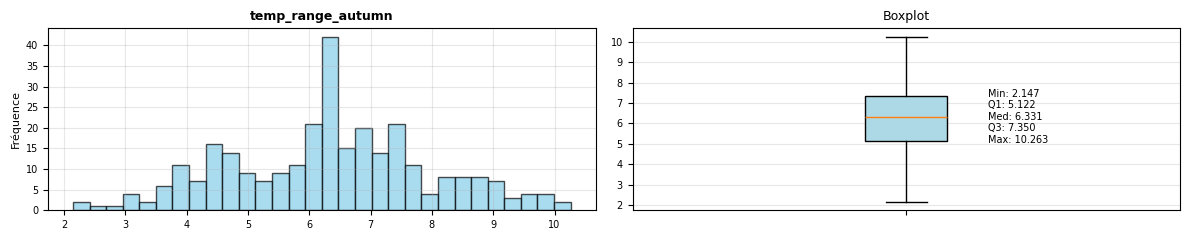

No outliers for temp_range_autumn



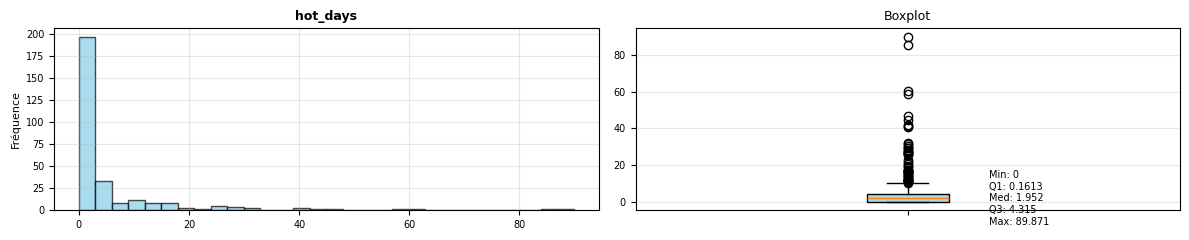

Outliers for hot_days (48 cities):
Valencia (10.581), Alicante (10.774), Zagreb (11.226), Granada (11.645), Lecce (11.710), Padova (11.839), Budapest (12.129), Chişinău (12.226), Toulouse (12.258), Prato (12.903), Skopje (13.516), Ravenna (14.000), Arezzo (14.677), Taranto (14.742), Catania (15.581), Nîmes (15.677), Oradea (16.387), Pécs (16.677), Parma (16.774), Modena (16.774), Firenze (17.129), Coimbra (17.613), Debrecen (18.774), Perugia (19.710), Avignon (20.806), Salamanca (21.871), Timişoara (22.774), Valladolid (25.742), Bucharest (26.226), Szeged (26.742), Bologna (26.839), Jerez de la Frontera (26.903), Novi Sad (27.548), Belgrade (28.000), Thessaloníki (29.129), Cagliari (29.581), Krasnodar (30.516), Ferrara (31.548), Elche (31.968), Zaragoza (40.581), Piraeus (41.161), Alcalá de Henares (41.613), Murcia (44.484), Madrid (46.645), Toledo (58.548), Athens (60.194), Córdoba (85.161), Sevilla (89.871)



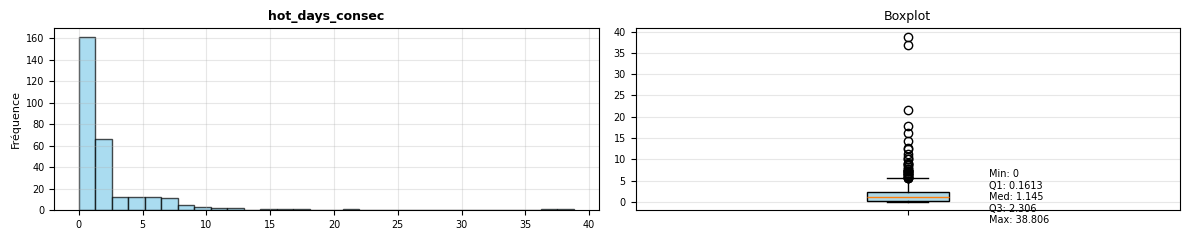

Outliers for hot_days_consec (36 cities):
Skopje (5.548), Prato (5.613), Coimbra (5.613), Ravenna (5.806), Catania (5.903), Arezzo (6.097), Nîmes (6.258), Taranto (6.548), Parma (6.613), Modena (6.677), Timişoara (6.710), Salamanca (6.806), Szeged (7.161), Belgrade (7.161), Novi Sad (7.194), Firenze (7.226), Perugia (7.290), Valladolid (7.742), Jerez de la Frontera (7.839), Avignon (8.323), Bucharest (8.581), Bologna (8.903), Elche (8.968), Thessaloníki (9.226), Zaragoza (10.065), Krasnodar (10.097), Ferrara (10.613), Cagliari (11.161), Murcia (12.452), Piraeus (12.645), Alcalá de Henares (14.419), Madrid (16.129), Athens (17.871), Toledo (21.484), Sevilla (36.839), Córdoba (38.806)


--- Summary for dataset: 1994-2024 ---

First 5 rows:
                city   latitude  longitude  sf_winter     sf_spring  \
0             Aachen  50.776642    6.08342   0.000442  2.974464e-05   
1           Aberdeen  57.143688   -2.09814   0.000253  3.000838e-05   
2    Aix-en-Provence  43.528301    5.44

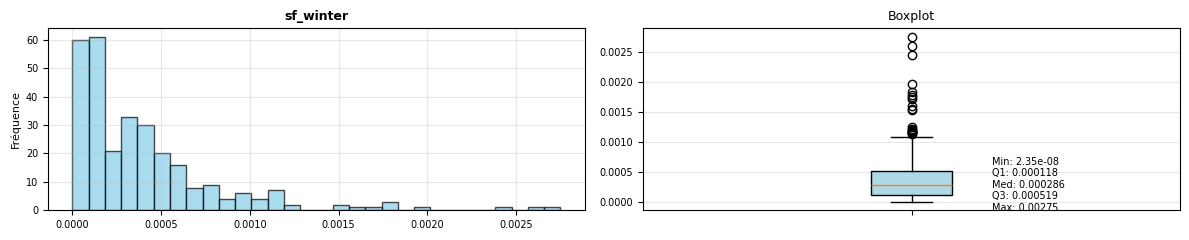

Outliers for sf_winter (20 cities):
Saint Petersburg (0.00113), Turin (0.00115), Helsinki (0.00115), Tampere (0.00116), Oulu (0.00116), Moscow (0.00118), Vantaa (0.00119), Espoo (0.00121), Yaroslavl' (0.00124), Oslo (0.00153), Zürich (0.00155), Sochi (0.00159), Lausanne (0.00172), Reykjavík (0.00174), Sarajevo (0.00177), Grenoble (0.00183), Bern (0.00196), Salzburg (0.00244), Bergen (0.00259), Innsbruck (0.00275)



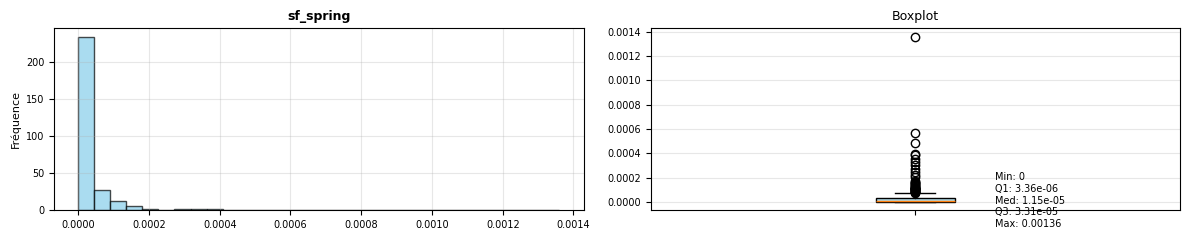

Outliers for sf_spring (37 cities):
Freiburg (7.8e-05), Vilnius (7.99e-05), Lublin (8.45e-05), Plovdiv (8.52e-05), Basel (8.58e-05), Turku (8.86e-05), Skopje (9.13e-05), Stockholm (9.48e-05), Sofia (0.000103), Bergamo (0.000105), Moscow (0.000107), Sochi (0.000108), Tallinn (0.00011), Kraków (0.000115), Helsinki (0.000116), Vantaa (0.000118), Espoo (0.000123), Yaroslavl' (0.000129), Ljubljana (0.000136), Saint Petersburg (0.000142), München (0.000145), Braşov (0.000156), Tampere (0.000159), Graz (0.000161), Como (0.000173), Oslo (0.000207), Oulu (0.000223), Sarajevo (0.000249), Reykjavík (0.000274), Bergen (0.000308), Lausanne (0.000327), Zürich (0.000357), Turin (0.00039), Grenoble (0.000393), Salzburg (0.000489), Bern (0.000564), Innsbruck (0.00136)



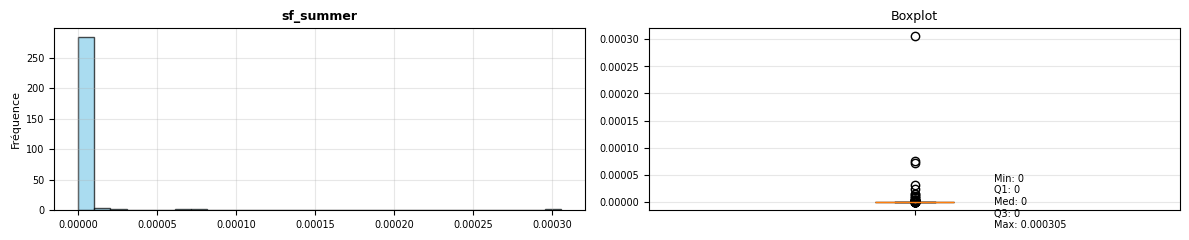

Outliers for sf_summer (57 cities):
Montpellier (1.6e-10), Glasgow (4.27e-10), Dresden (4.27e-10), Ostrava (4.27e-10), Newcastle upon Tyne (4.27e-10), Trieste (1.28e-09), Katowice (1.71e-09), Brno (3.53e-09), Prague (3.85e-09), Oviedo (4.49e-09), Wrocław (4.7e-09), Tirana (7.05e-09), Kraków (8.01e-09), Besançon (8.83e-09), Tampere (1.03e-08), Nürnberg (2.22e-08), Chemnitz (2.28e-08), Skopje (3.12e-08), Mulhouse (3.85e-08), Plzeň (5.47e-08), Regensburg (6.92e-08), Basel (8.46e-08), Kiev (8.6e-08), Verona (9.38e-08), Stuttgart (1.33e-07), Ploieşti (1.87e-07), Sofia (1.91e-07), Saint Petersburg (1.96e-07), Saint-Étienne (2.33e-07), Sochi (2.41e-07), Nice (2.93e-07), Clermont-Ferrand (3.01e-07), Plovdiv (3.07e-07), Freiburg (3.65e-07), Brescia (5.25e-07), Oslo (6.31e-07), Augsburg (6.62e-07), Ljubljana (7.67e-07), Cluj-Napoca (8.29e-07), Braşov (1.37e-06), Moscow (1.54e-06), Bergamo (1.59e-06), Oulu (2.56e-06), München (2.91e-06), Yaroslavl' (3.14e-06), Sarajevo (3.78e-06), Bergen (3.82e-0

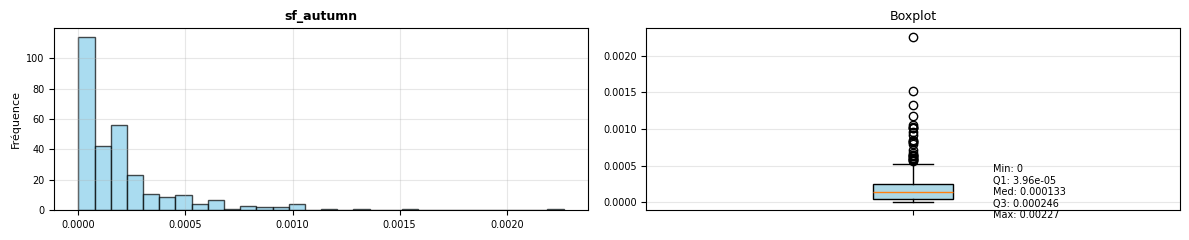

Outliers for sf_autumn (27 cities):
Tallinn (0.000562), Como (0.000579), Sofia (0.000579), München (0.000586), Braşov (0.000606), Graz (0.000609), Helsinki (0.000629), Ljubljana (0.000636), Espoo (0.000645), Vantaa (0.000648), Sochi (0.000666), Tampere (0.000719), Oslo (0.000795), Saint Petersburg (0.000819), Moscow (0.000825), Turin (0.00084), Oulu (0.000847), Reykjavík (0.000921), Yaroslavl' (0.000953), Zürich (0.00101), Bergen (0.00102), Sarajevo (0.00103), Lausanne (0.00105), Grenoble (0.00118), Bern (0.00133), Salzburg (0.00152), Innsbruck (0.00227)



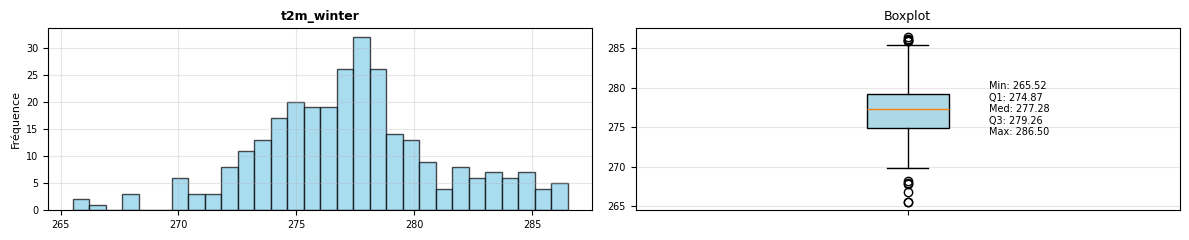

Outliers for t2m_winter (11 cities):
Yaroslavl' (265.52), Oulu (265.53), Moscow (266.79), Saint Petersburg (267.85), Innsbruck (267.90), Tampere (268.22), Siracusa (285.92), Jerez de la Frontera (285.98), Palma (286.05), Cartagena (286.18), Marsala (286.50)



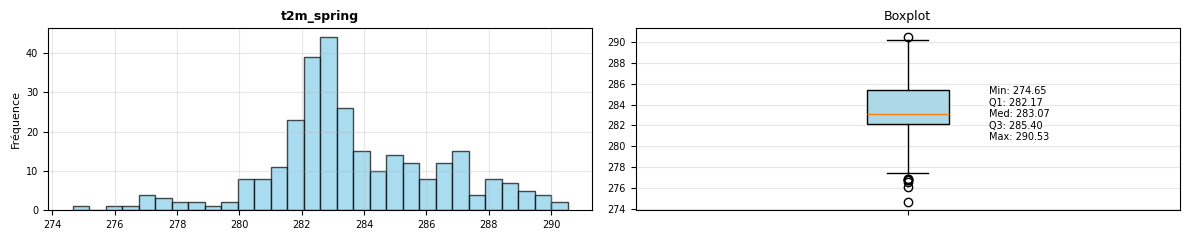

Outliers for t2m_spring (8 cities):
Oulu (274.65), Innsbruck (276.08), Helsinki (276.58), Espoo (276.79), Reykjavík (276.81), Tampere (276.82), Vantaa (276.87), Sevilla (290.53)



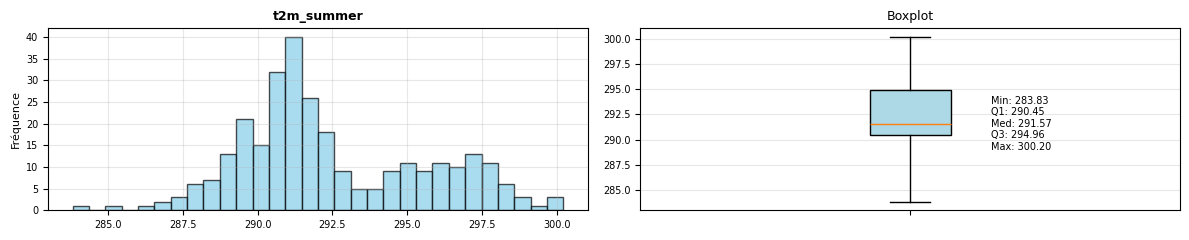

No outliers for t2m_summer



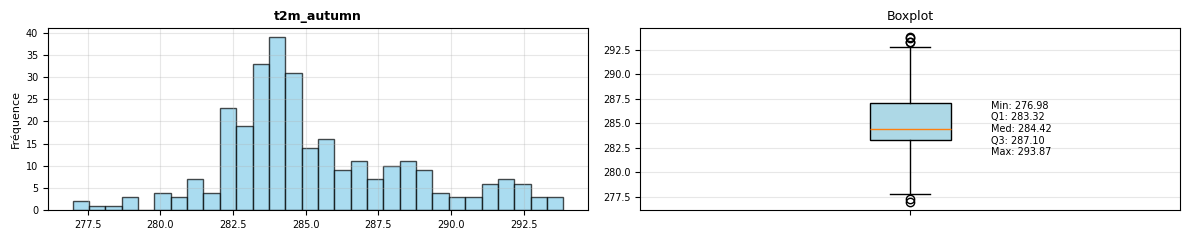

Outliers for t2m_autumn (6 cities):
Oulu (276.98), Innsbruck (277.33), Cartagena (293.27), Palma (293.32), Siracusa (293.71), Marsala (293.87)



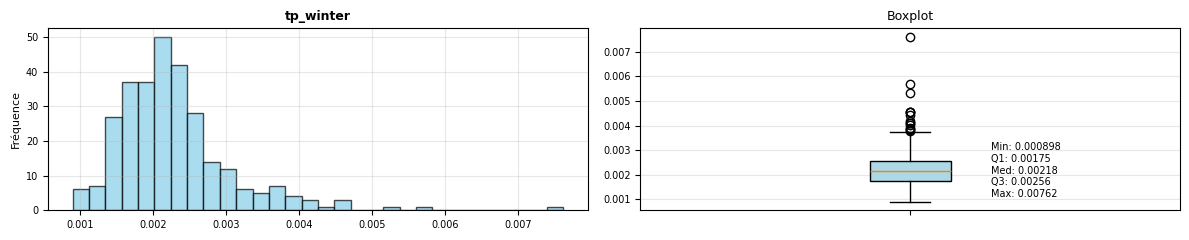

Outliers for tp_winter (15 cities):
Santander (0.00379), Lausanne (0.00382), Salzburg (0.00387), Gijón (0.00392), Donostia / San Sebastián (0.00403), Salerno (0.00409), Glasgow (0.0041), Tirana (0.00417), Sochi (0.00445), Santiago de Compostela (0.00455), Reykjavík (0.00455), Porto (0.00457), Braga (0.00532), Vigo (0.00568), Bergen (0.00762)



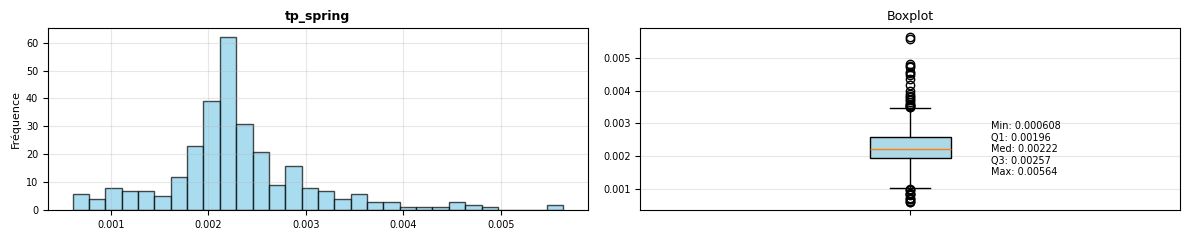

Outliers for tp_spring (36 cities):
Piraeus (0.000608), Cartagena (0.000614), Siracusa (0.000647), Athens (0.000688), Roquetas de Mar (0.000703), Marsala (0.000722), Murcia (0.000823), Almería (0.000843), Palma (0.000847), Elche (0.000893), Málaga (0.000959), Marbella (0.000978), Alicante (0.000995), Freiburg (0.00351), Verona (0.00351), Braga (0.00352), Besançon (0.00355), Vigo (0.00356), Graz (0.00359), Trieste (0.00365), Brescia (0.0037), Sarajevo (0.00373), Milan (0.0038), Basel (0.00385), München (0.00388), Ljubljana (0.00398), Grenoble (0.00416), Bergamo (0.00436), Bergen (0.00449), Turin (0.00454), Lausanne (0.00458), Zürich (0.00471), Como (0.00473), Bern (0.00481), Salzburg (0.00557), Innsbruck (0.00564)



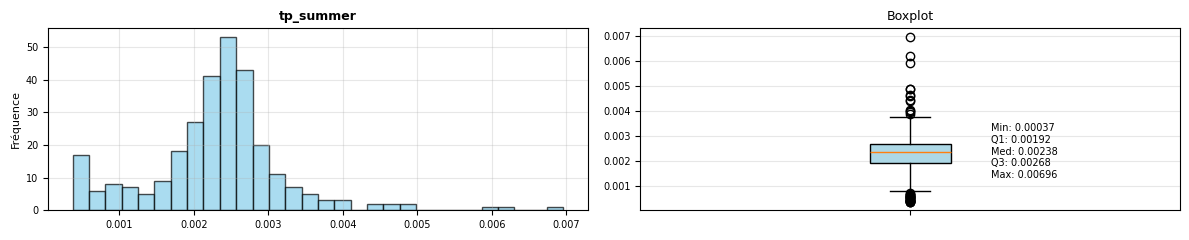

Outliers for tp_summer (36 cities):
Piraeus (0.00037), Roquetas de Mar (0.000383), Jerez de la Frontera (0.000387), Athens (0.00039), Sevilla (0.000404), Málaga (0.00041), Setúbal (0.000417), Marbella (0.000433), Lisbon (0.000446), Córdoba (0.00046), Cagliari (0.000498), Almería (0.000512), Granada (0.00054), Cartagena (0.00055), Toledo (0.000567), Alcalá de Henares (0.000588), Madrid (0.000589), Marsala (0.000607), Salamanca (0.000648), Valladolid (0.000657), Murcia (0.000665), Elche (0.000682), Siracusa (0.000742), Trieste (0.00386), Reykjavík (0.00394), Graz (0.00401), München (0.00403), Bergamo (0.00439), Ljubljana (0.00445), Lausanne (0.00461), Como (0.00462), Bern (0.00489), Zürich (0.00489), Salzburg (0.00592), Innsbruck (0.0062), Bergen (0.00696)



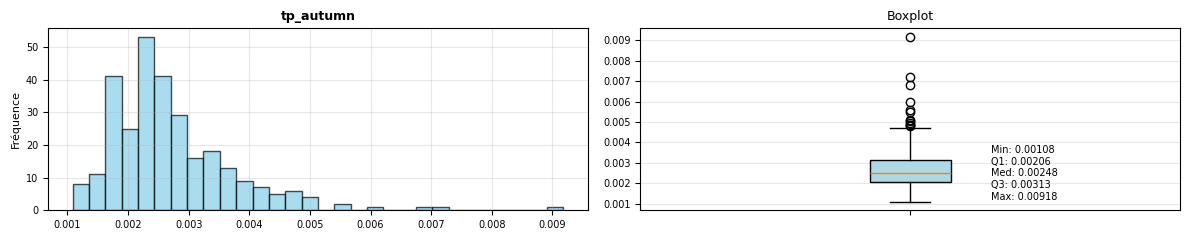

Outliers for tp_autumn (12 cities):
Blackpool (0.00482), Napoli (0.00485), Pisa (0.00487), Split (0.00494), Trieste (0.00507), Salerno (0.00508), La Spezia (0.00548), Santiago de Compostela (0.00559), Porto (0.006), Braga (0.00679), Vigo (0.00719), Bergen (0.00918)



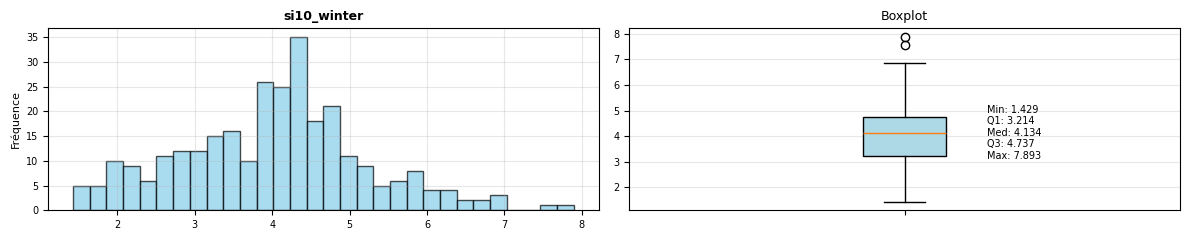

Outliers for si10_winter (2 cities):
Eastbourne (7.573), Brest (7.893)



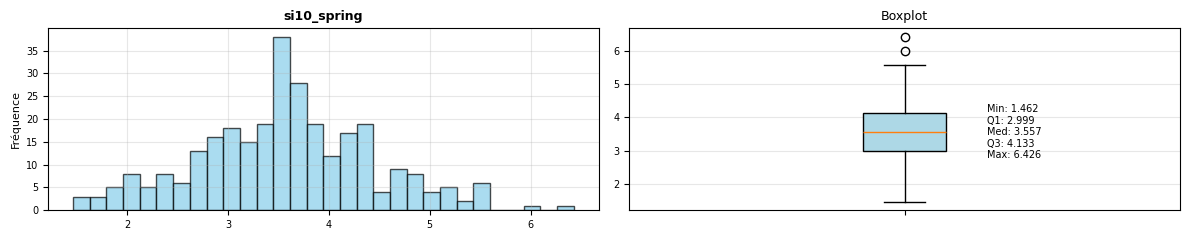

Outliers for si10_spring (2 cities):
Eastbourne (5.997), Brest (6.426)



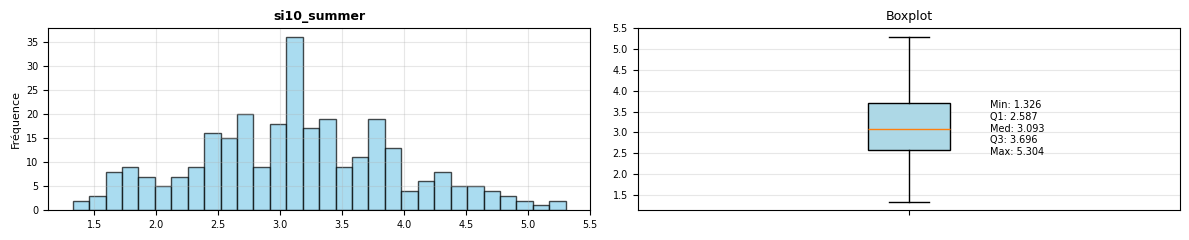

No outliers for si10_summer



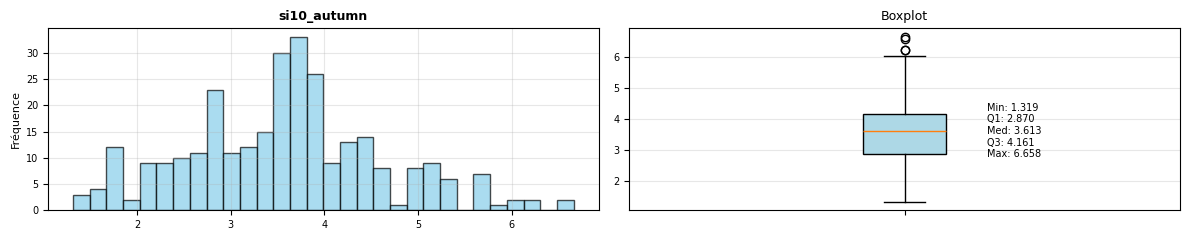

Outliers for si10_autumn (4 cities):
Aberdeen (6.212), Blackpool (6.215), Brest (6.585), Eastbourne (6.658)



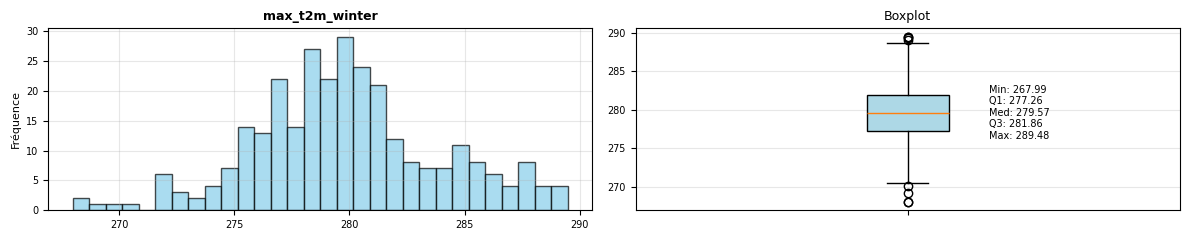

Outliers for max_t2m_winter (8 cities):
Yaroslavl' (267.99), Oulu (267.99), Moscow (269.18), Saint Petersburg (270.02), Elche (289.05), Murcia (289.34), Jerez de la Frontera (289.40), Sevilla (289.48)



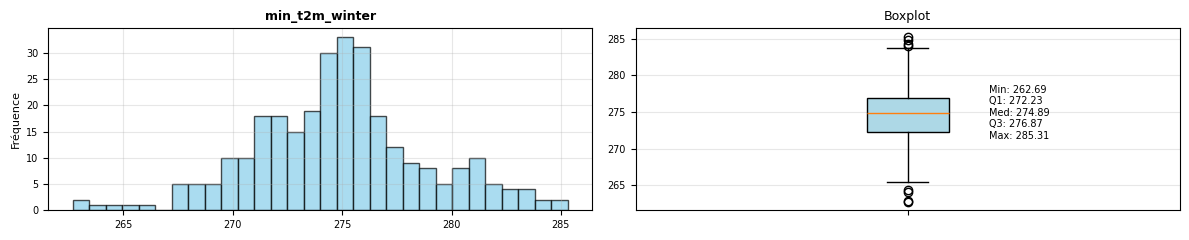

Outliers for min_t2m_winter (8 cities):
Yaroslavl' (262.69), Oulu (262.76), Moscow (264.08), Innsbruck (264.31), Cartagena (283.99), Siracusa (284.27), Palma (284.84), Marsala (285.31)



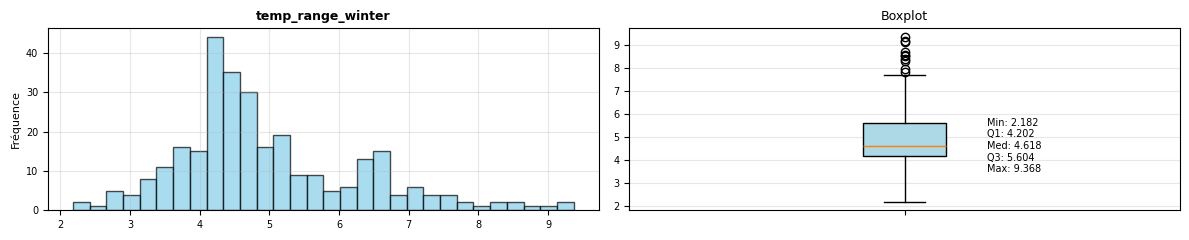

Outliers for temp_range_winter (10 cities):
Sofia (7.816), Granada (7.948), Zaragoza (8.314), Elche (8.377), Madrid (8.529), Toledo (8.550), Alcalá de Henares (8.683), Sevilla (9.114), Murcia (9.162), Córdoba (9.368)



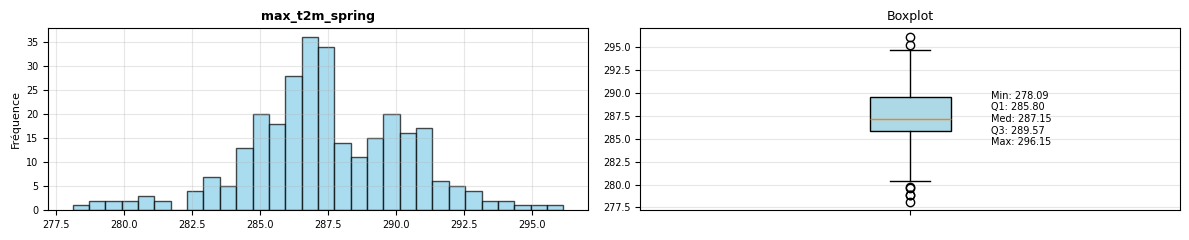

Outliers for max_t2m_spring (7 cities):
Oulu (278.09), Reykjavík (278.89), Helsinki (278.91), Espoo (279.61), Vantaa (279.70), Córdoba (295.23), Sevilla (296.15)



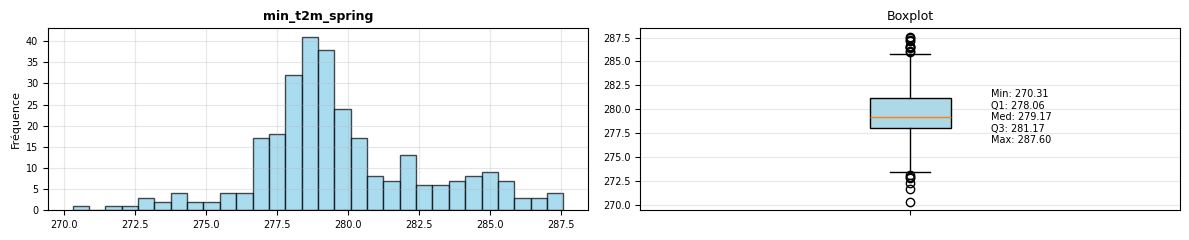

Outliers for min_t2m_spring (16 cities):
Oulu (270.31), Innsbruck (271.66), Tampere (272.30), Saint Petersburg (272.80), Yaroslavl' (272.91), Turku (273.15), Palermo (285.98), Marbella (286.13), Messina (286.44), Lecce (286.46), Roquetas de Mar (286.55), Jerez de la Frontera (286.60), Siracusa (287.10), Cartagena (287.27), Palma (287.43), Marsala (287.60)



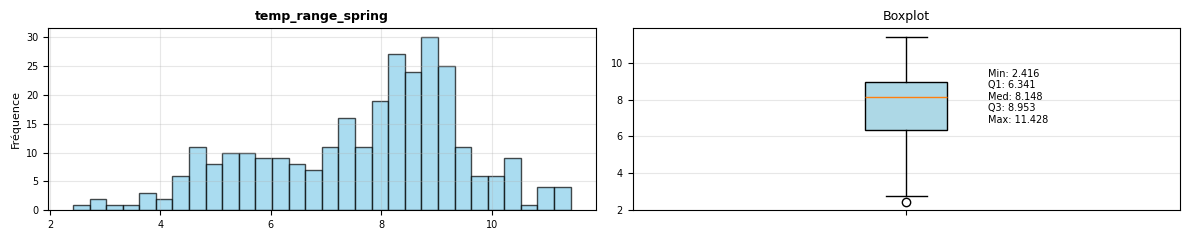

Outliers for temp_range_spring (1 cities):
Brest (2.416)



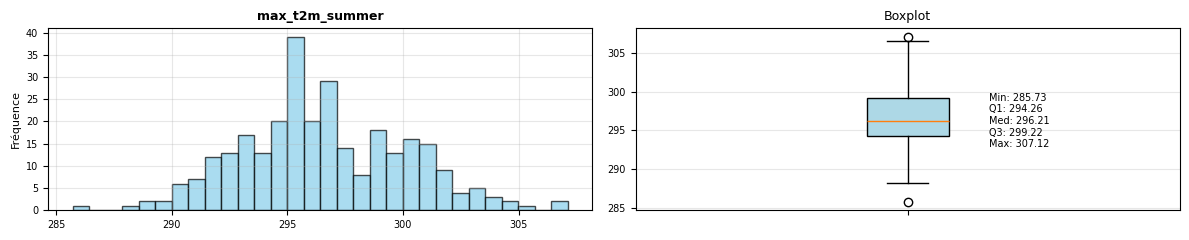

Outliers for max_t2m_summer (2 cities):
Reykjavík (285.73), Córdoba (307.12)



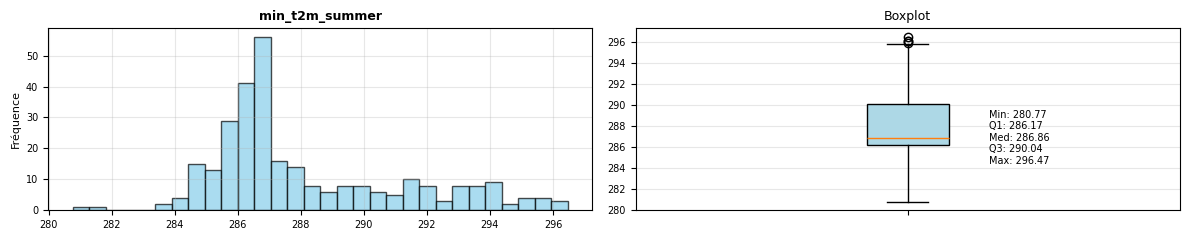

Outliers for min_t2m_summer (4 cities):
Lecce (295.90), Palma (296.07), Marsala (296.09), Siracusa (296.47)



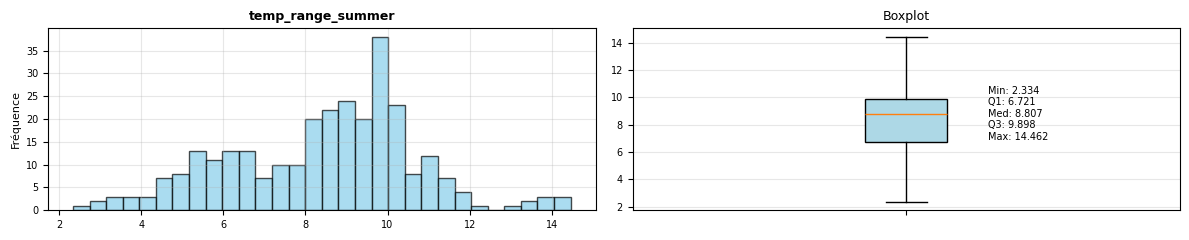

No outliers for temp_range_summer



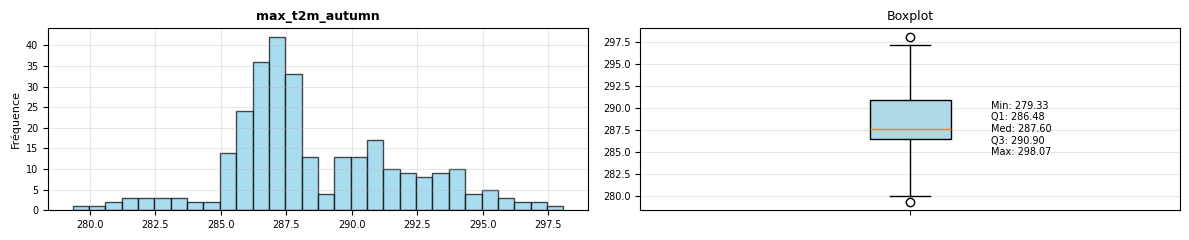

Outliers for max_t2m_autumn (2 cities):
Oulu (279.33), Sevilla (298.07)



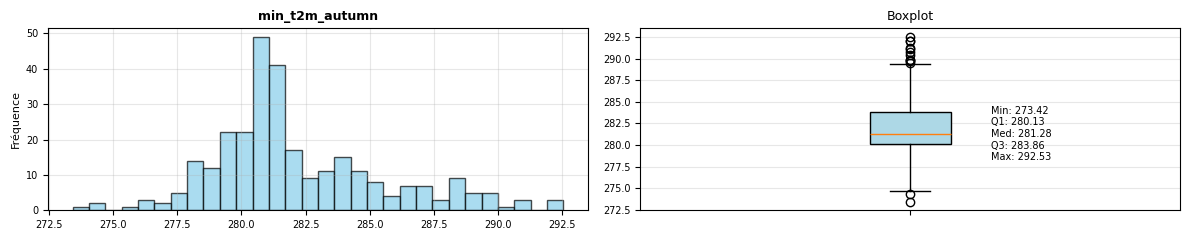

Outliers for min_t2m_autumn (13 cities):
Innsbruck (273.42), Oulu (274.34), Jerez de la Frontera (289.54), Piraeus (289.73), Roquetas de Mar (289.85), Catania (289.88), Lecce (290.41), Palermo (290.74), Cartagena (291.13), Messina (291.24), Palma (292.00), Siracusa (292.05), Marsala (292.53)



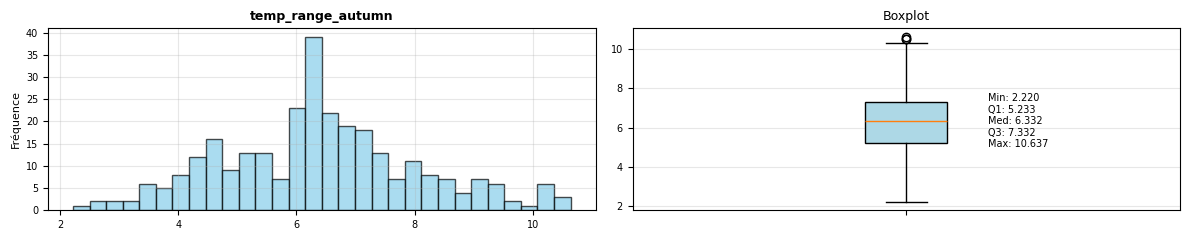

Outliers for temp_range_autumn (3 cities):
Skopje (10.501), Alcalá de Henares (10.511), Córdoba (10.637)



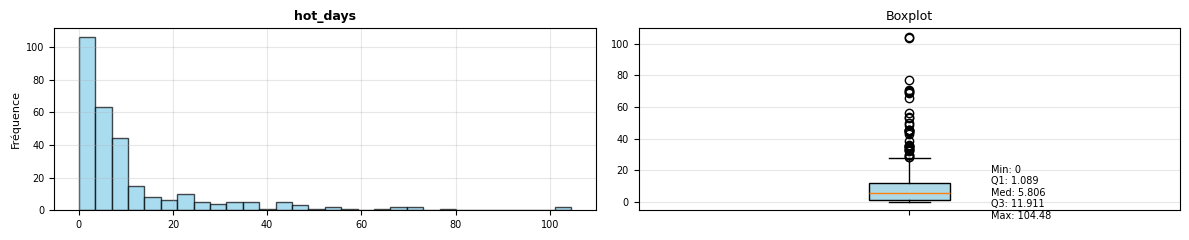

Outliers for hot_days (35 cities):
Ravenna (28.290), Padova (28.355), Perugia (29.613), Oradea (29.774), Modena (31.935), Milan (32.742), Granada (32.742), Skopje (33.516), Salamanca (33.871), Timişoara (35.032), Debrecen (35.226), Parma (35.226), Nîmes (35.548), Szeged (36.129), Jerez de la Frontera (38.516), Avignon (42.677), Novi Sad (44.065), Belgrade (44.516), Bucharest (45.097), Valladolid (45.226), Krasnodar (45.290), Bologna (45.677), Thessaloníki (48.613), Cagliari (50.032), Piraeus (52.903), Elche (53.645), Ferrara (56.323), Murcia (65.806), Alcalá de Henares (68.774), Zaragoza (69.194), Madrid (70.065), Athens (70.742), Toledo (76.871), Sevilla (103.81), Córdoba (104.48)



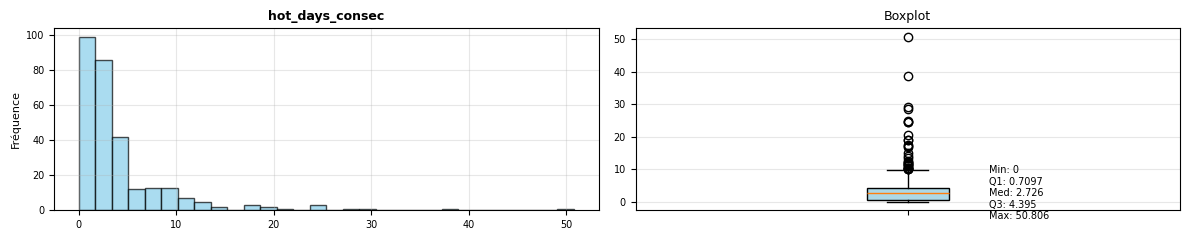

Outliers for hot_days_consec (30 cities):
Jerez de la Frontera (10.032), Timişoara (10.065), Debrecen (10.097), Modena (10.355), Perugia (10.419), Padova (10.484), Belgrade (10.935), Novi Sad (11.258), Milan (11.387), Nîmes (11.806), Parma (11.871), Valladolid (12.129), Granada (12.258), Bucharest (12.710), Bologna (13.387), Avignon (14.226), Krasnodar (15.161), Piraeus (16.935), Thessaloníki (17.097), Ferrara (17.484), Zaragoza (18.935), Cagliari (19.000), Elche (20.581), Athens (24.645), Madrid (24.710), Alcalá de Henares (24.839), Toledo (28.645), Murcia (29.065), Sevilla (38.774), Córdoba (50.806)


--- Summary for dataset: 2021-2050_ssp126 ---

First 5 rows:
                city   latitude  longitude   hot_days  hot_days_consec  \
0             Aachen  50.776642    6.08342   8.900000         3.000000   
1           Aberdeen  57.143688   -2.09814   0.000000         0.000000   
2    Aix-en-Provence  43.528301    5.44973  27.933333        12.533333   
3  Alcalá de Henares  40.482052 

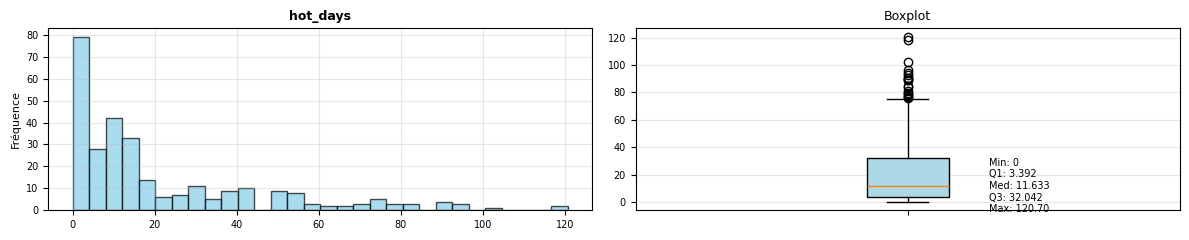

Outliers for hot_days (18 cities):
Madrid (75.700), Marsala (76.367), Zaragoza (77.600), Lecce (79.000), Granada (79.800), Alcalá de Henares (81.300), Málaga (83.800), Valencia (84.300), Jerez de la Frontera (88.900), Murcia (89.267), Athens (90.400), Alicante (90.533), Thessaloníki (92.667), Piraeus (94.000), Toledo (96.500), Elche (102.03), Sevilla (118.10), Córdoba (120.70)



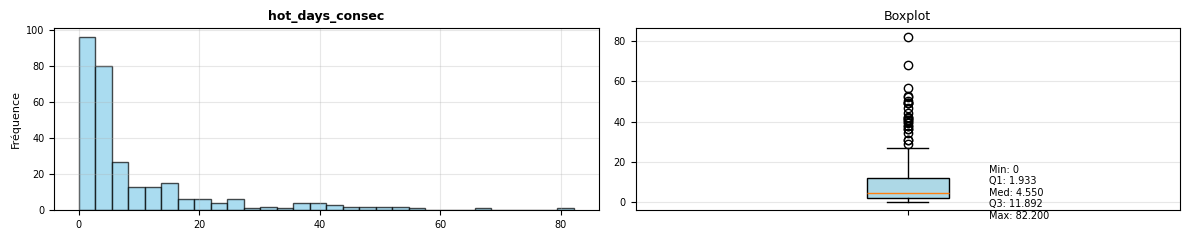

Outliers for hot_days_consec (26 cities):
Salerno (29.000), Napoli (30.867), Zaragoza (30.900), Siracusa (34.433), Bari (36.133), Rome (36.267), Roquetas de Mar (37.600), Madrid (37.700), Almería (39.033), Alcalá de Henares (39.600), Valencia (40.567), Jerez de la Frontera (40.867), Málaga (41.533), Marsala (41.900), Taranto (42.200), Lecce (44.233), Athens (46.567), Granada (49.233), Murcia (49.267), Thessaloníki (49.433), Alicante (50.333), Piraeus (52.100), Toledo (52.733), Elche (56.433), Sevilla (67.900), Córdoba (82.200)



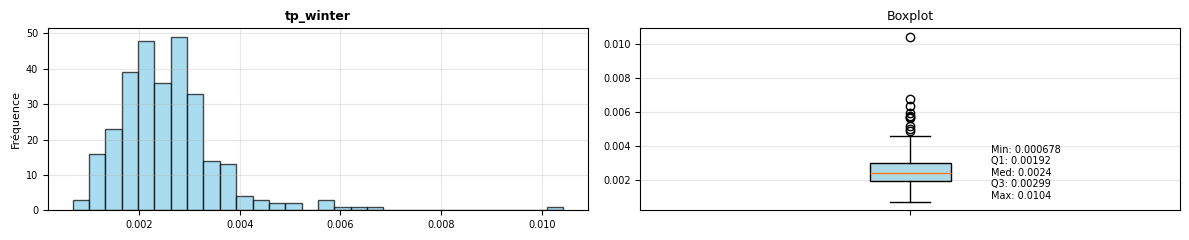

Outliers for tp_winter (10 cities):
Donostia / San Sebastián (0.00487), Lausanne (0.005), Porto (0.00513), Santiago de Compostela (0.00561), Braga (0.00568), Glasgow (0.00575), Reykjavík (0.00595), Vigo (0.00631), Sochi (0.00674), Bergen (0.0104)



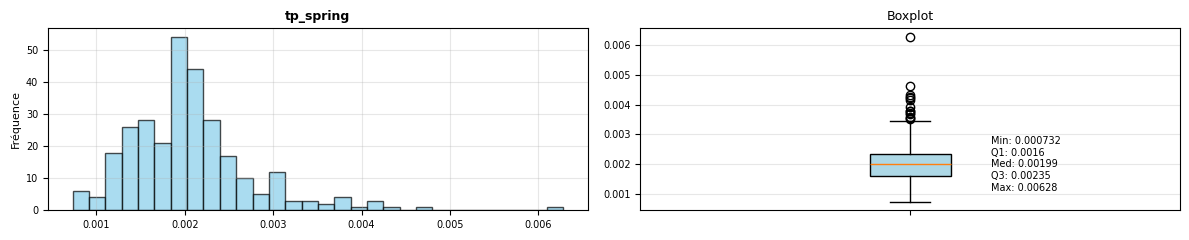

Outliers for tp_spring (14 cities):
Innsbruck (0.00351), Santiago de Compostela (0.00355), Zürich (0.00359), Ljubljana (0.00369), Pamplona (0.00372), Donostia / San Sebastián (0.00377), Bern (0.00378), Vigo (0.00392), Lausanne (0.00415), Sochi (0.00423), Salzburg (0.00424), Reykjavík (0.00431), Como (0.00462), Bergen (0.00628)



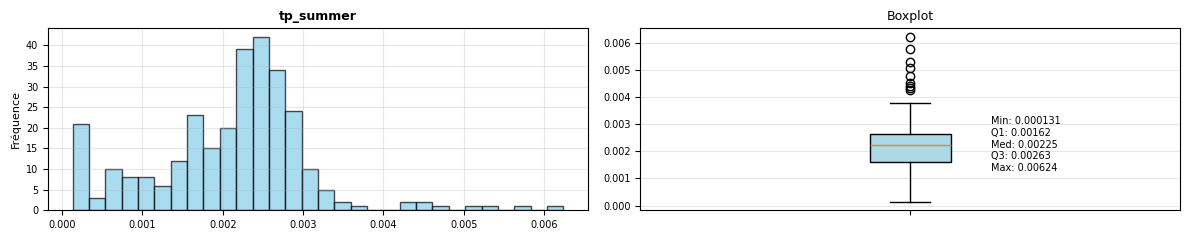

Outliers for tp_summer (9 cities):
Bern (0.00425), Graz (0.00433), Zürich (0.00443), Ljubljana (0.00452), Como (0.00478), München (0.00509), Bergen (0.0053), Innsbruck (0.00577), Salzburg (0.00624)



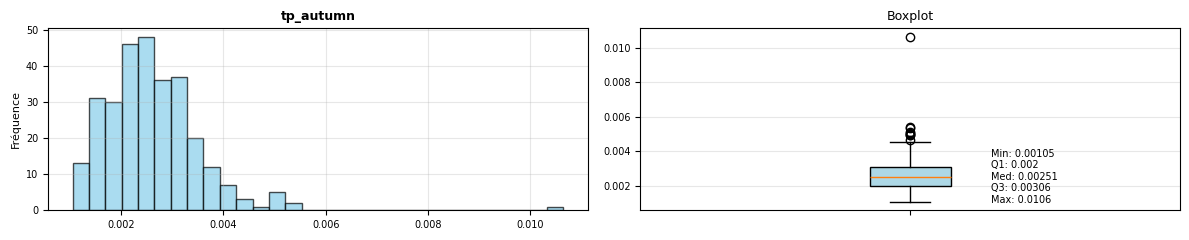

Outliers for tp_autumn (9 cities):
Trieste (0.00465), Rome (0.00492), Reykjavík (0.00494), Ljubljana (0.00499), Vigo (0.00504), Como (0.0051), Glasgow (0.00535), Sochi (0.00539), Bergen (0.0106)



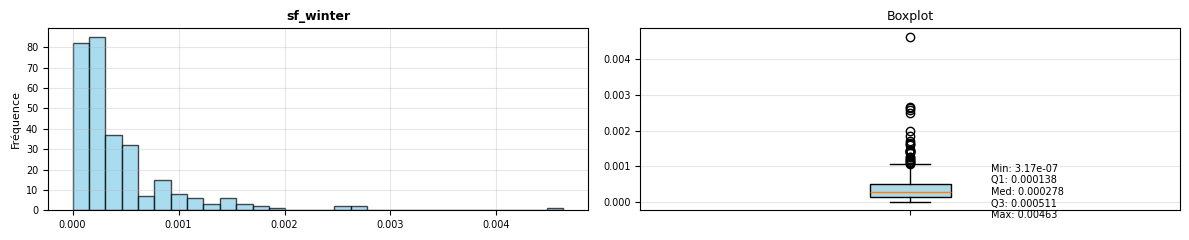

Outliers for sf_winter (27 cities):
Sarajevo (0.00107), Stockholm (0.00111), Turku (0.00113), Vilnius (0.00113), München (0.00117), Saint Petersburg (0.00119), Braşov (0.0012), Ljubljana (0.00126), Como (0.00127), Grenoble (0.00136), Zürich (0.00141), Oulu (0.00141), Tampere (0.00142), Vantaa (0.00144), Moscow (0.00146), Yaroslavl' (0.00146), Helsinki (0.00158), Tallinn (0.00161), Bern (0.00166), Espoo (0.0017), Oslo (0.00184), Lausanne (0.00198), Reykjavík (0.00249), Salzburg (0.00257), Sochi (0.00263), Innsbruck (0.00267), Bergen (0.00463)



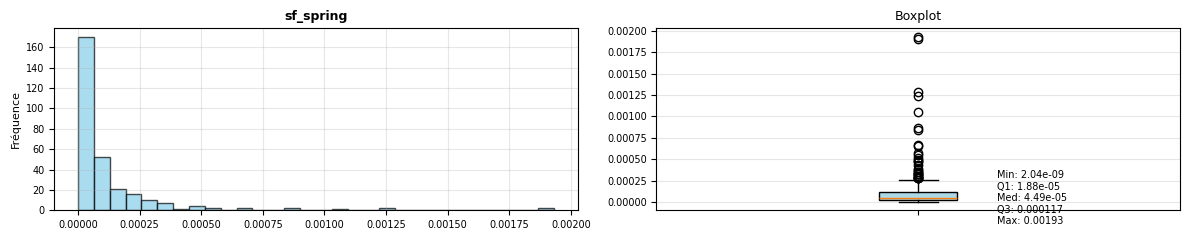

Outliers for sf_spring (30 cities):
Glasgow (0.000281), Lublin (0.000281), Vantaa (0.000282), Brescia (0.000282), Helsinki (0.000288), Graz (0.000306), Moscow (0.000307), Ljubljana (0.000325), Plovdiv (0.000327), Yaroslavl' (0.000332), Kraków (0.000346), Espoo (0.000349), Tampere (0.000374), Sarajevo (0.000385), Turin (0.000428), Braşov (0.000464), Oulu (0.000477), Sofia (0.000495), München (0.000513), Grenoble (0.000546), Zürich (0.000574), Sochi (0.000653), Oslo (0.000661), Bern (0.000838), Lausanne (0.000864), Como (0.00105), Salzburg (0.00124), Reykjavík (0.00128), Innsbruck (0.0019), Bergen (0.00193)



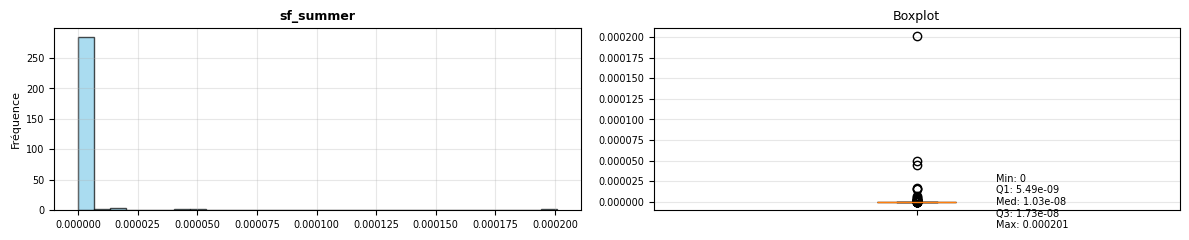

Outliers for sf_summer (61 cities):
Zagreb (3.79e-08), Nîmes (3.87e-08), Saint Petersburg (4.16e-08), Salamanca (5.01e-08), Regensburg (5.6e-08), Saint-Étienne (5.77e-08), Lyon (5.87e-08), Espoo (6.75e-08), La Spezia (8.18e-08), Vienna (8.28e-08), Brno (8.69e-08), Lucca (9.93e-08), Parma (1.11e-07), Prato (1.11e-07), Ferrara (1.71e-07), Bologna (1.93e-07), Santander (1.96e-07), Modena (1.96e-07), Sofia (2.05e-07), Toledo (2.19e-07), Skopje (2.59e-07), Graz (2.68e-07), Oviedo (3.16e-07), Donostia / San Sebastián (3.88e-07), Cluj-Napoca (4.34e-07), Gijón (4.6e-07), Bilbao (4.79e-07), Bergamo (5.47e-07), Moscow (5.83e-07), Reykjavík (5.86e-07), Burgos (6.33e-07), Venezia (6.37e-07), Ljubljana (6.94e-07), Ploieşti (6.94e-07), Milan (7e-07), Padova (7.06e-07), Zaragoza (7.41e-07), Brescia (8.41e-07), Pamplona (9.08e-07), Alcalá de Henares (1.03e-06), Freiburg (1.07e-06), Madrid (1.08e-06), Mestre (1.09e-06), Split (1.15e-06), Grenoble (1.28e-06), Sarajevo (1.31e-06), Bergen (1.55e-06), Vero

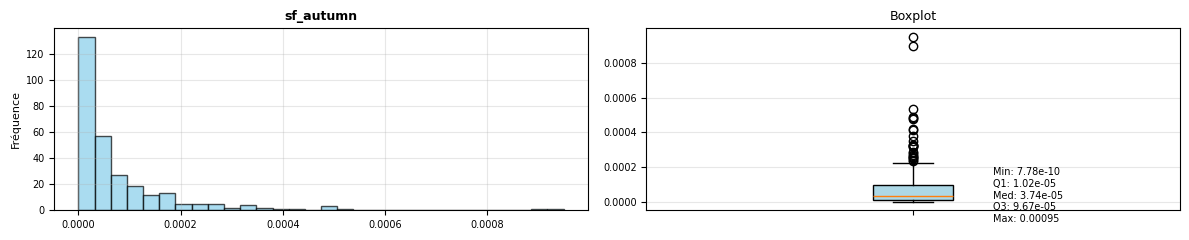

Outliers for sf_autumn (24 cities):
Espoo (0.000235), Tampere (0.000243), Ploieşti (0.000253), Sarajevo (0.000255), Sofia (0.000259), Grenoble (0.000264), Verona (0.000271), Brescia (0.000281), Saint Petersburg (0.00029), Sochi (0.000315), Graz (0.000321), Oslo (0.000323), Yaroslavl' (0.000329), Moscow (0.00033), Braşov (0.000348), Oulu (0.00038), Ljubljana (0.000411), Lausanne (0.000422), Bern (0.000479), Salzburg (0.000484), Reykjavík (0.000491), Como (0.000532), Innsbruck (0.000894), Bergen (0.00095)



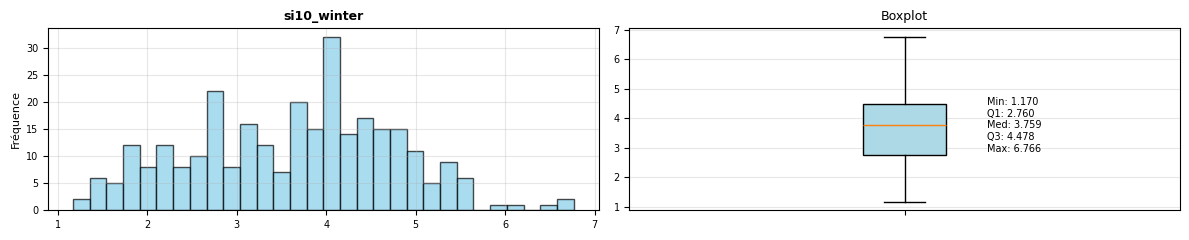

No outliers for si10_winter



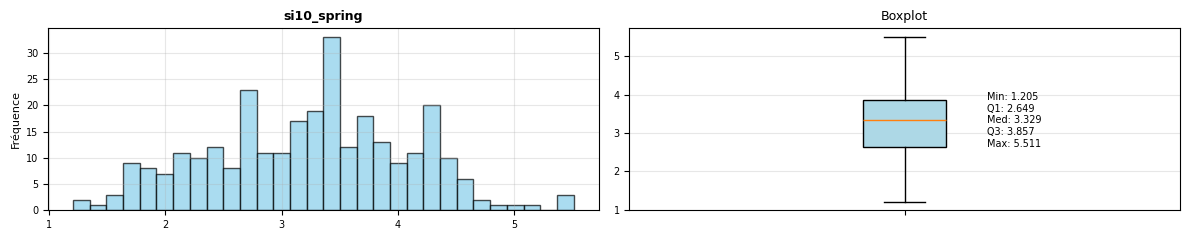

No outliers for si10_spring



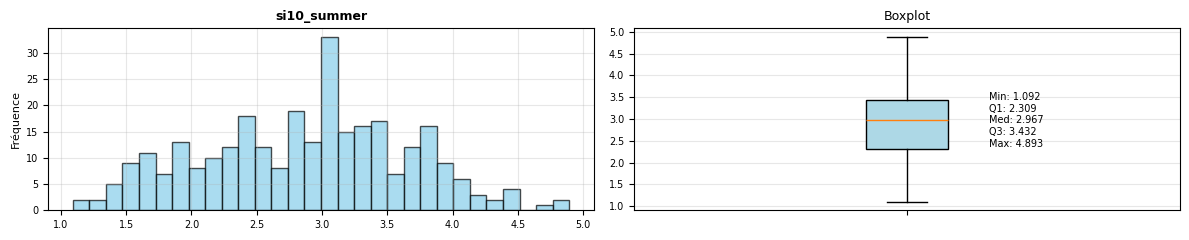

No outliers for si10_summer



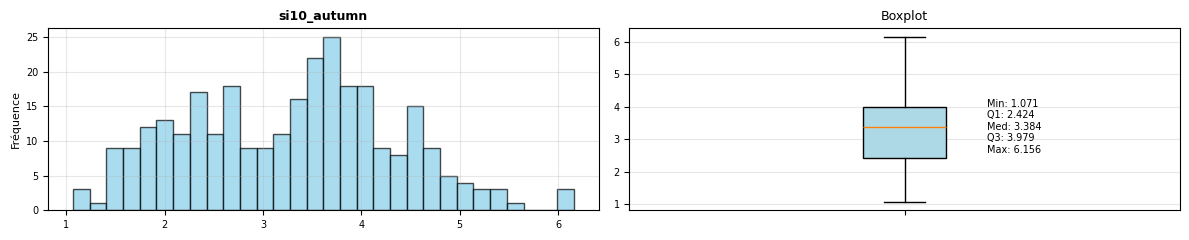

No outliers for si10_autumn



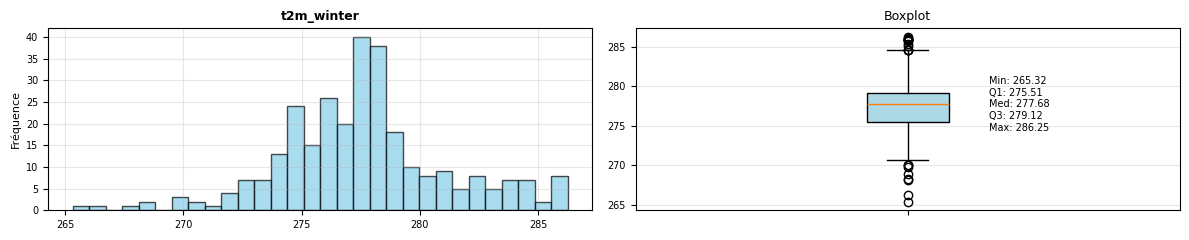

Outliers for t2m_winter (21 cities):
Oulu (265.32), Yaroslavl' (266.17), Tampere (268.08), Moscow (268.29), Saint Petersburg (268.81), Espoo (269.75), Vantaa (269.95), Oslo (270.04), Palermo (284.54), Málaga (284.60), Messina (284.60), Roquetas de Mar (285.04), Elche (285.38), Palma (285.68), Marsala (285.76), Marbella (285.80), Lisbon (285.88), Cartagena (285.90), Jerez de la Frontera (286.01), Siracusa (286.10), Setúbal (286.25)



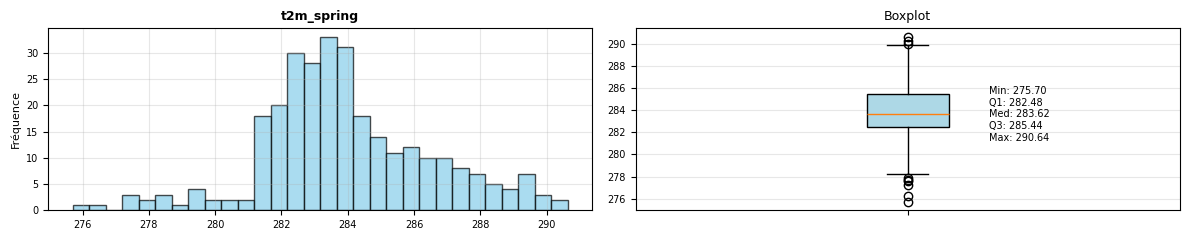

Outliers for t2m_spring (9 cities):
Oulu (275.70), Reykjavík (276.25), Innsbruck (277.22), Helsinki (277.58), Tampere (277.67), Tallinn (277.85), Elche (290.00), Sevilla (290.28), Jerez de la Frontera (290.64)



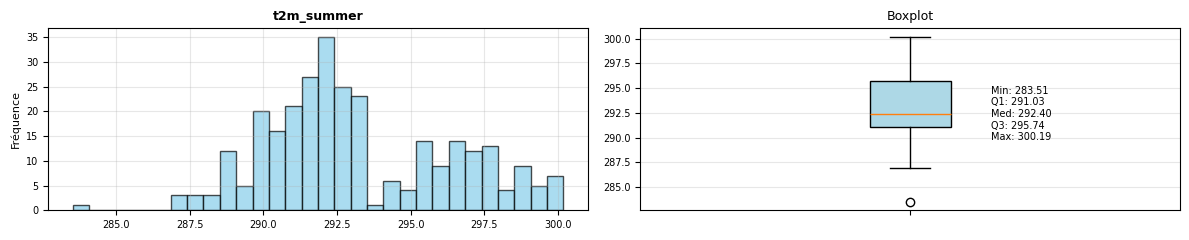

Outliers for t2m_summer (1 cities):
Reykjavík (283.51)



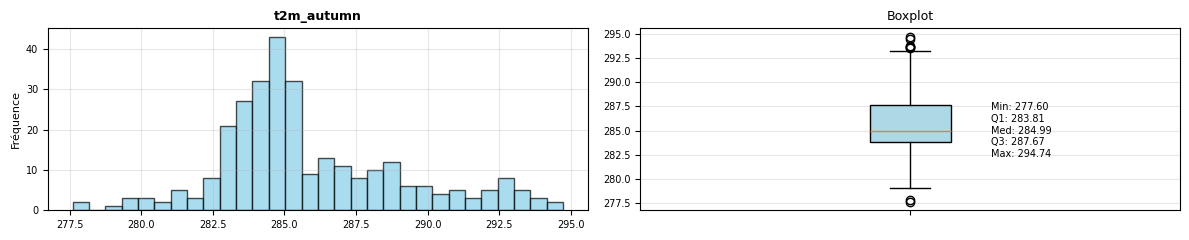

Outliers for t2m_autumn (8 cities):
Oulu (277.60), Reykjavík (277.83), Elche (293.58), Palma (293.66), Cartagena (293.68), Jerez de la Frontera (293.76), Marsala (294.44), Siracusa (294.74)



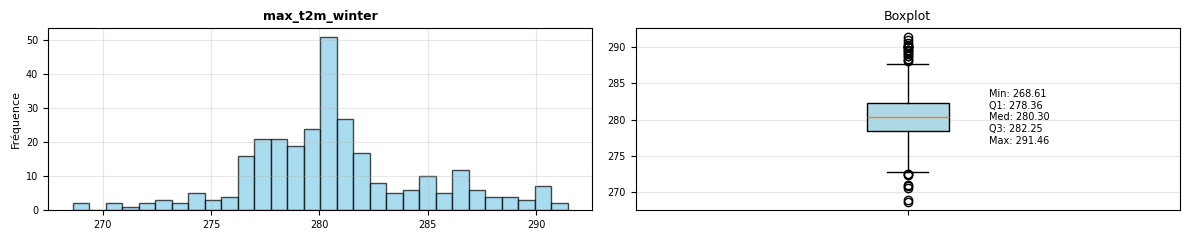

Outliers for max_t2m_winter (27 cities):
Oulu (268.61), Yaroslavl' (268.90), Moscow (270.61), Tampere (270.82), Saint Petersburg (270.94), Espoo (272.39), Vantaa (272.42), Oslo (272.43), Palma (288.15), Porto (288.26), Almería (288.30), Córdoba (288.73), Marsala (288.75), Siracusa (289.01), Coimbra (289.14), Cartagena (289.45), Valencia (289.60), Setúbal (289.68), Lisbon (289.97), Marbella (290.02), Málaga (290.03), Alicante (290.03), Murcia (290.19), Sevilla (290.27), Roquetas de Mar (290.56), Jerez de la Frontera (291.04), Elche (291.46)



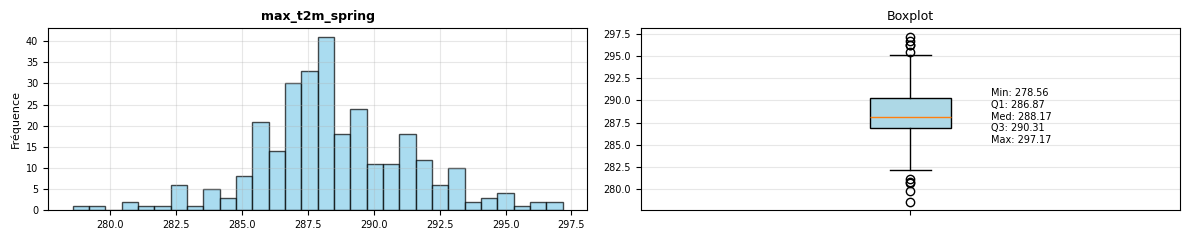

Outliers for max_t2m_spring (10 cities):
Reykjavík (278.56), Oulu (279.76), Helsinki (280.74), Tallinn (280.81), Innsbruck (281.12), Málaga (295.47), Elche (296.18), Jerez de la Frontera (296.26), Córdoba (296.66), Sevilla (297.17)



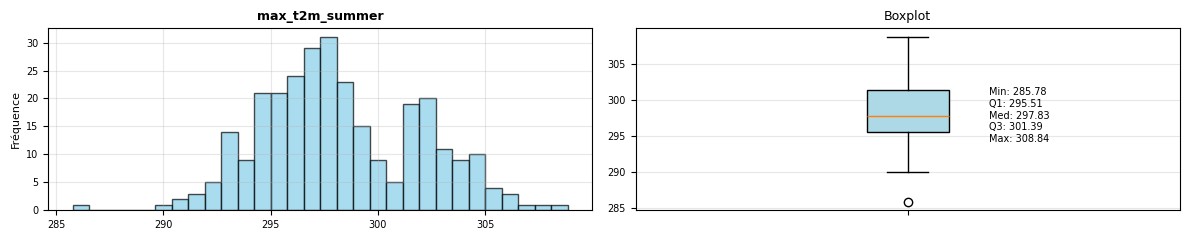

Outliers for max_t2m_summer (1 cities):
Reykjavík (285.78)



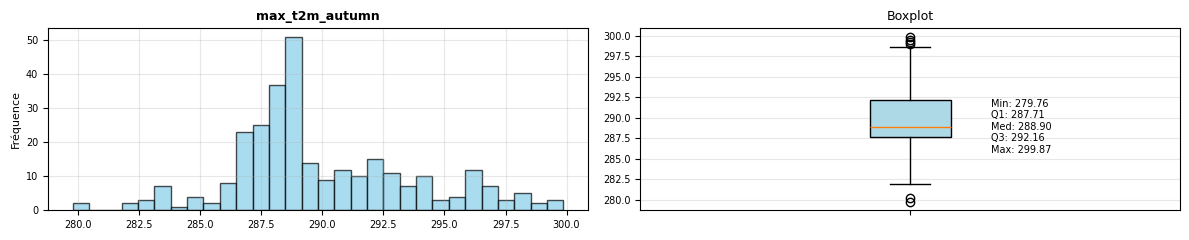

Outliers for max_t2m_autumn (6 cities):
Reykjavík (279.76), Oulu (280.30), Córdoba (299.00), Jerez de la Frontera (299.27), Elche (299.49), Sevilla (299.87)



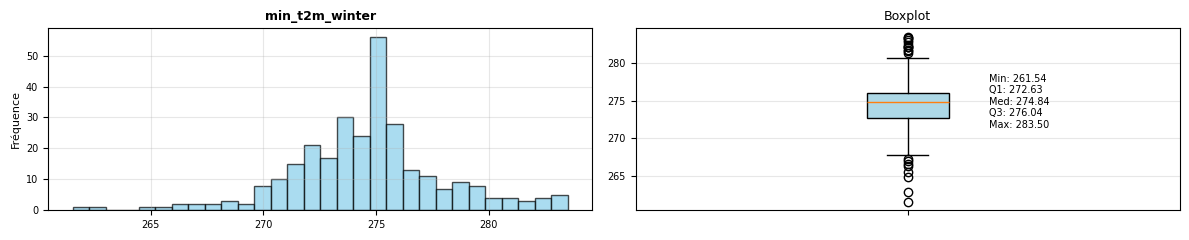

Outliers for min_t2m_winter (20 cities):
Oulu (261.54), Yaroslavl' (262.93), Tampere (264.91), Moscow (265.48), Saint Petersburg (266.31), Espoo (266.60), Vantaa (266.99), Oslo (267.32), Toulon (281.38), Jerez de la Frontera (281.62), Catania (281.77), Palermo (282.08), Marbella (282.17), Messina (282.18), Lisbon (282.44), Marsala (282.81), Cartagena (282.99), Palma (283.27), Setúbal (283.33), Siracusa (283.50)



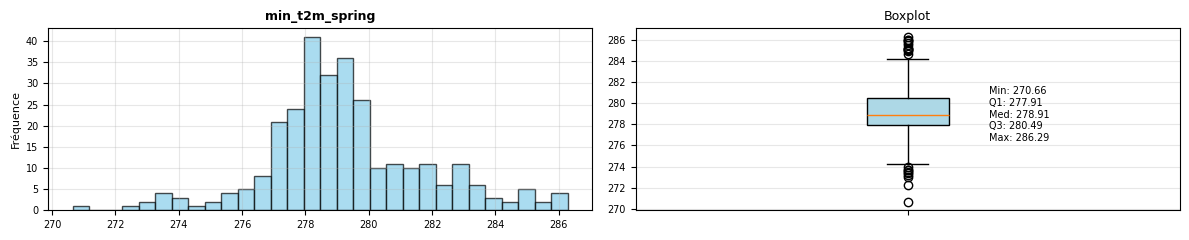

Outliers for min_t2m_spring (21 cities):
Oulu (270.66), Tampere (272.26), Espoo (273.01), Innsbruck (273.25), Oslo (273.36), Vantaa (273.51), Reykjavík (273.64), Turku (273.68), Helsinki (274.01), Toulon (284.68), Catania (284.90), Palermo (284.99), Jerez de la Frontera (285.08), Marbella (285.13), Messina (285.19), Lisbon (285.47), Marsala (285.71), Palma (285.88), Setúbal (285.95), Cartagena (285.98), Siracusa (286.29)



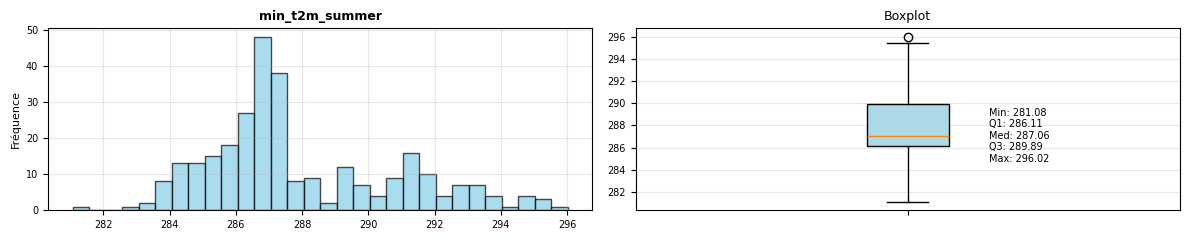

Outliers for min_t2m_summer (1 cities):
Siracusa (296.02)



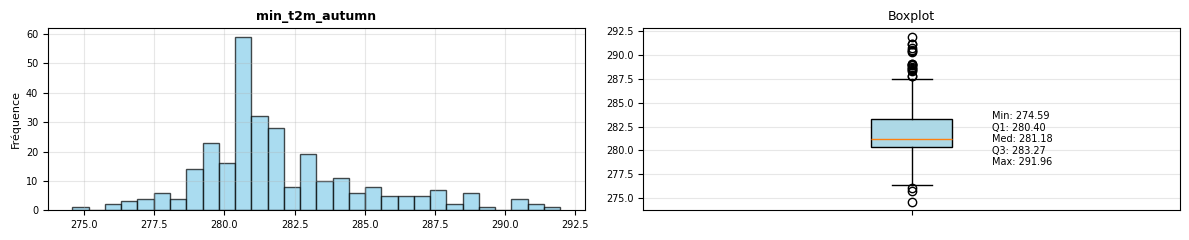

Outliers for min_t2m_autumn (21 cities):
Oulu (274.59), Reykjavík (275.78), Tampere (276.01), Salerno (287.78), Taranto (287.82), Elche (288.38), Roquetas de Mar (288.40), Lisbon (288.55), Lecce (288.61), Toulon (288.81), Jerez de la Frontera (288.93), Cagliari (288.96), Setúbal (289.04), Marbella (289.08), Catania (290.32), Messina (290.47), Palermo (290.52), Cartagena (290.75), Palma (291.17), Marsala (291.21), Siracusa (291.96)



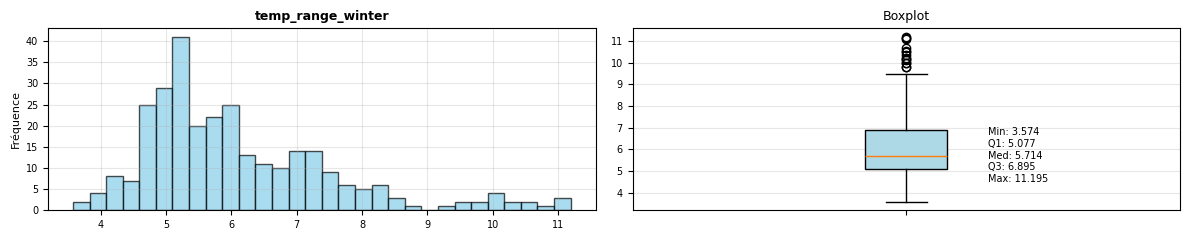

Outliers for temp_range_winter (14 cities):
Madrid (9.779), Zaragoza (9.791), Roquetas de Mar (9.959), Málaga (9.996), Alcalá de Henares (10.103), Almería (10.157), Toledo (10.204), Granada (10.347), Valencia (10.506), Sevilla (10.554), Alicante (10.687), Murcia (11.101), Córdoba (11.135), Elche (11.195)



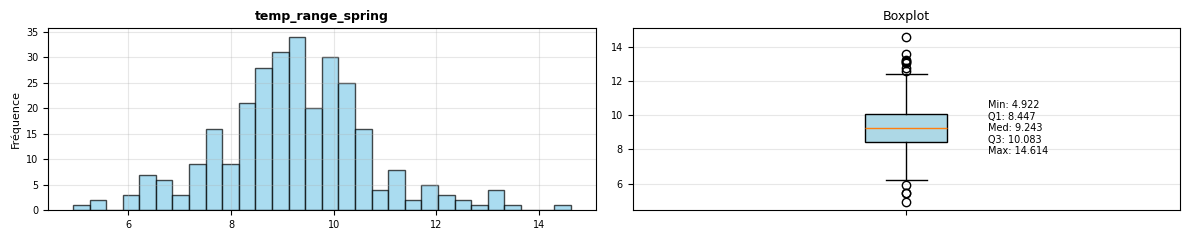

Outliers for temp_range_spring (12 cities):
Reykjavík (4.922), Palma (5.438), Toulon (5.477), Aberdeen (5.909), Madrid (12.600), Valladolid (12.764), Alcalá de Henares (13.072), Salamanca (13.107), Toledo (13.157), Zaragoza (13.271), Sevilla (13.618), Córdoba (14.614)



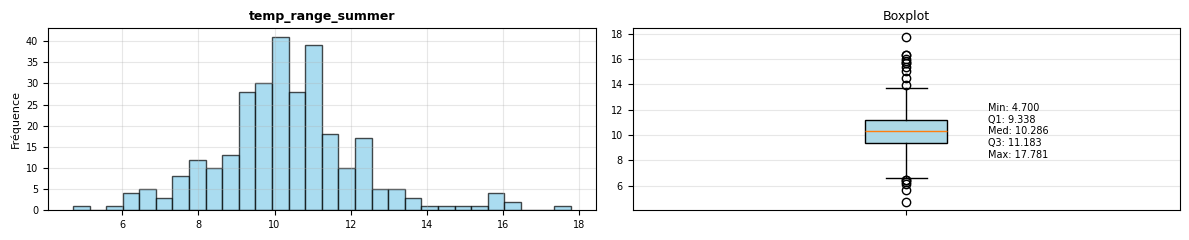

Outliers for temp_range_summer (17 cities):
Reykjavík (4.700), Palma (5.660), Toulon (6.157), Aberdeen (6.256), Tallinn (6.416), Donostia / San Sebastián (6.417), Bucharest (13.969), Burgos (14.521), Granada (15.066), Madrid (15.342), Toledo (15.685), Zaragoza (15.704), Valladolid (15.853), Alcalá de Henares (15.993), Salamanca (16.314), Sevilla (16.331), Córdoba (17.781)



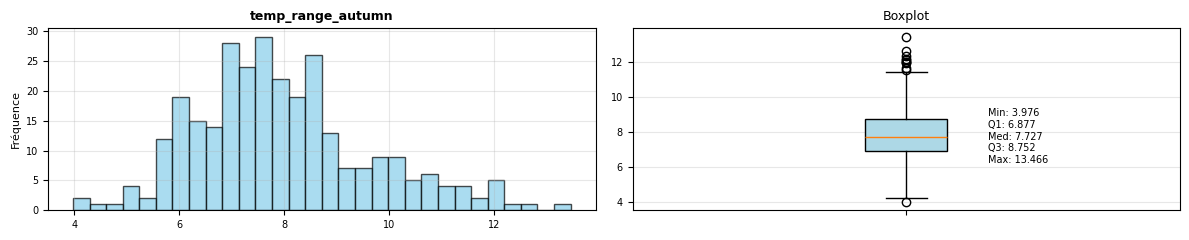

Outliers for temp_range_autumn (11 cities):
Reykjavík (3.976), Bucharest (11.576), Madrid (11.643), Granada (11.936), Zaragoza (11.992), Valladolid (12.022), Alcalá de Henares (12.130), Toledo (12.165), Salamanca (12.359), Sevilla (12.634), Córdoba (13.466)


--- Summary for dataset: 2021-2050_ssp370 ---

First 5 rows:
                city   latitude  longitude   hot_days  hot_days_consec  \
0             Aachen  50.776642    6.08342  10.633333         4.000000   
1           Aberdeen  57.143688   -2.09814   0.000000         0.000000   
2    Aix-en-Provence  43.528301    5.44973  31.100000        13.466667   
3  Alcalá de Henares  40.482052   -3.35996  81.233333        44.766667   
4           Alicante  38.345169   -0.48149  88.366667        59.700000   

   tp_winter  tp_spring  tp_summer  tp_autumn  sf_winter  ...  max_t2m_summer  \
0   0.003185   0.002094   0.002427   0.002466   0.000320  ...       297.14420   
1   0.002553   0.001769   0.002016   0.002913   0.000153  ...       290.

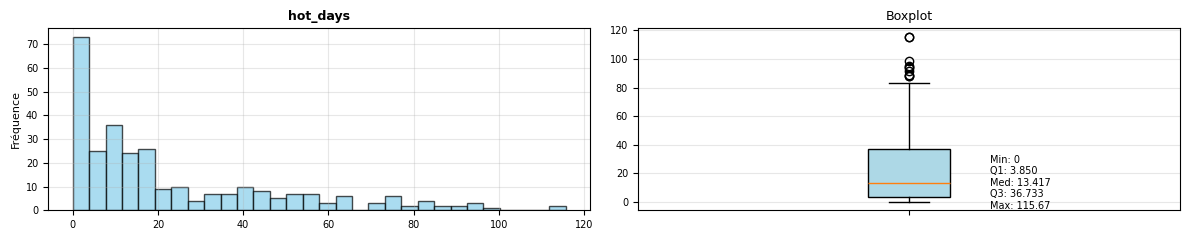

Outliers for hot_days (10 cities):
Murcia (87.900), Alicante (88.367), Jerez de la Frontera (88.833), Athens (91.533), Toledo (93.700), Thessaloníki (94.567), Piraeus (95.433), Elche (98.533), Córdoba (115.60), Sevilla (115.67)



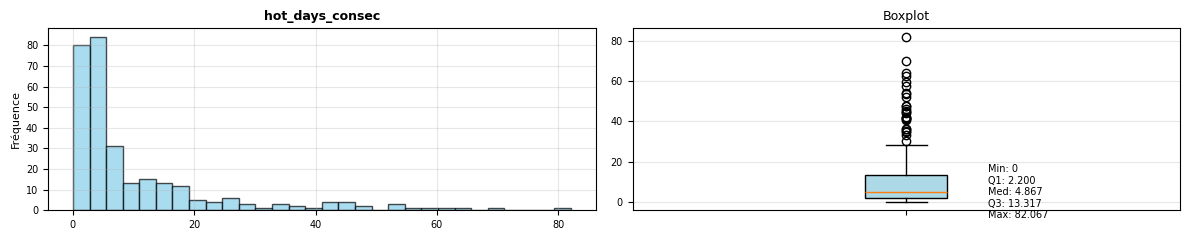

Outliers for hot_days_consec (26 cities):
Salerno (30.433), Bari (33.300), Zaragoza (34.933), Siracusa (35.267), Rome (36.067), Napoli (36.333), Taranto (40.700), Jerez de la Frontera (41.267), Roquetas de Mar (41.767), Almería (41.867), Madrid (42.200), Lecce (44.100), Alcalá de Henares (44.767), Marsala (45.100), Málaga (46.267), Valencia (47.767), Athens (47.867), Piraeus (52.233), Thessaloníki (53.400), Granada (54.033), Murcia (57.367), Alicante (59.700), Toledo (62.767), Elche (64.167), Sevilla (70.067), Córdoba (82.067)



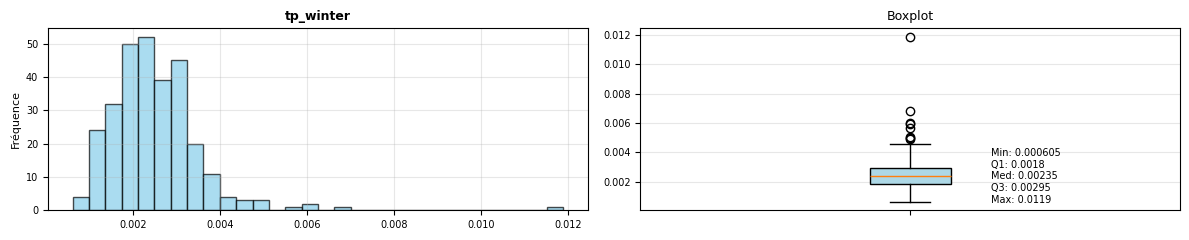

Outliers for tp_winter (8 cities):
Santiago de Compostela (0.00488), Braga (0.00496), Lausanne (0.00506), Vigo (0.00563), Glasgow (0.0059), Reykjavík (0.006), Sochi (0.0068), Bergen (0.0119)



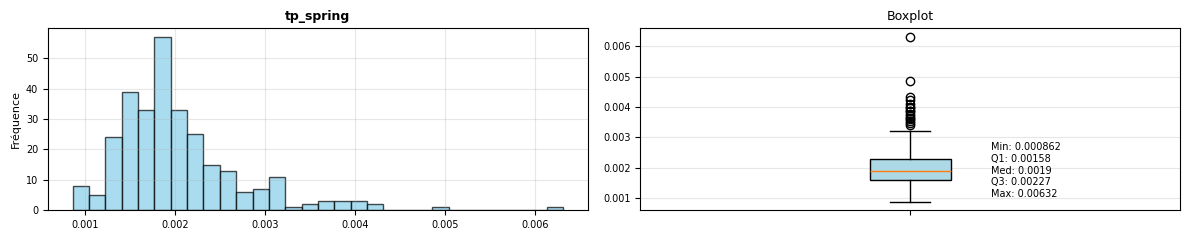

Outliers for tp_spring (16 cities):
Glasgow (0.00341), Braga (0.00348), Innsbruck (0.00353), Zürich (0.00359), Santiago de Compostela (0.00364), Bern (0.00371), Pamplona (0.00377), Donostia / San Sebastián (0.00387), Ljubljana (0.00387), Sochi (0.00396), Vigo (0.00398), Lausanne (0.00409), Salzburg (0.00423), Reykjavík (0.00431), Como (0.00487), Bergen (0.00632)



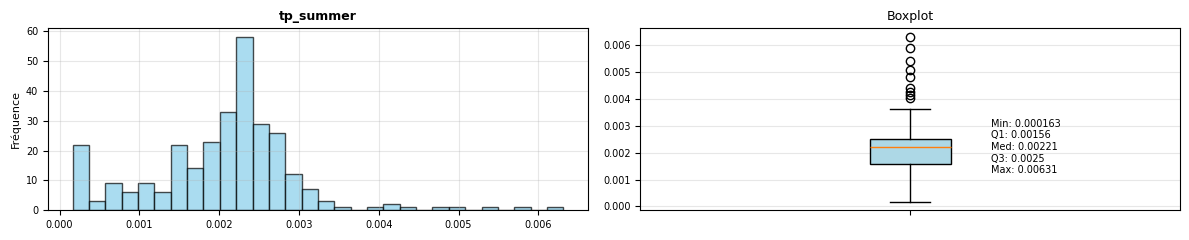

Outliers for tp_summer (9 cities):
Bern (0.00401), Graz (0.00415), Zürich (0.00425), Ljubljana (0.00439), Como (0.00483), München (0.00508), Bergen (0.0054), Innsbruck (0.0059), Salzburg (0.00631)



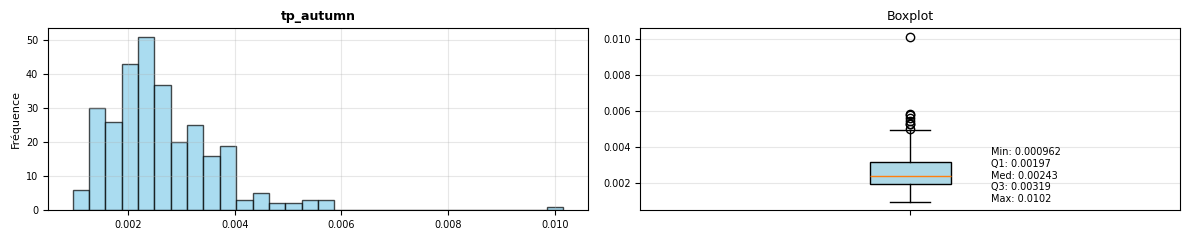

Outliers for tp_autumn (8 cities):
La Spezia (0.00504), Ljubljana (0.0053), Glasgow (0.0053), Rome (0.00546), Sochi (0.00562), Como (0.0058), Vigo (0.00584), Bergen (0.0102)



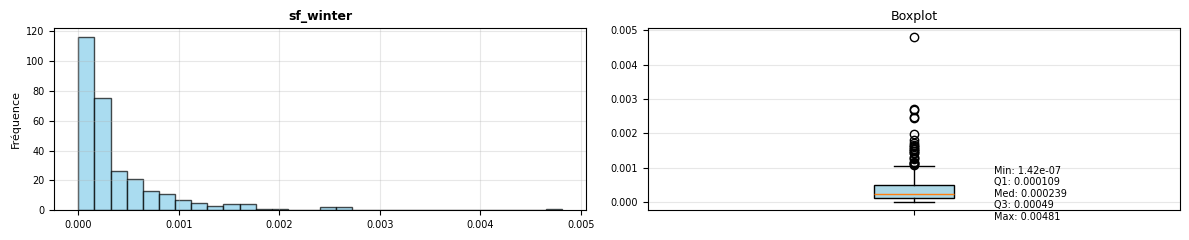

Outliers for sf_winter (25 cities):
Braşov (0.00107), Stockholm (0.0011), Turku (0.00114), Vilnius (0.00115), München (0.00116), Como (0.00125), Saint Petersburg (0.00127), Grenoble (0.00131), Tampere (0.00142), Oulu (0.00143), Vantaa (0.00148), Zürich (0.00149), Yaroslavl' (0.00154), Moscow (0.00154), Helsinki (0.00161), Tallinn (0.00164), Bern (0.00167), Espoo (0.00173), Oslo (0.00182), Lausanne (0.00198), Salzburg (0.00245), Innsbruck (0.00248), Reykjavík (0.00268), Sochi (0.00269), Bergen (0.00481)



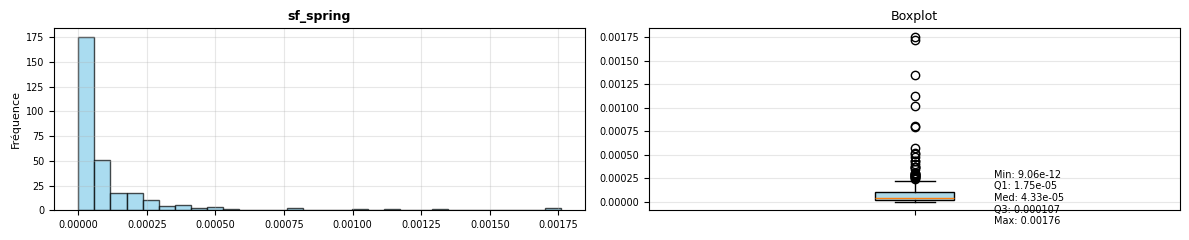

Outliers for sf_spring (32 cities):
Lublin (0.000241), Ljubljana (0.000252), Plovdiv (0.000266), Turku (0.000269), Saint Petersburg (0.000271), Graz (0.000279), Yaroslavl' (0.00028), Tallinn (0.000282), Moscow (0.000284), Vantaa (0.000292), Brescia (0.000299), Helsinki (0.000301), Kraków (0.000307), Sarajevo (0.000313), Espoo (0.000354), Tampere (0.000372), Sofia (0.000376), Braşov (0.000377), Oulu (0.000405), Turin (0.000432), München (0.000441), Grenoble (0.000478), Sochi (0.000505), Zürich (0.000522), Oslo (0.000576), Lausanne (0.000797), Bern (0.000812), Como (0.00102), Salzburg (0.00113), Reykjavík (0.00135), Bergen (0.00172), Innsbruck (0.00176)



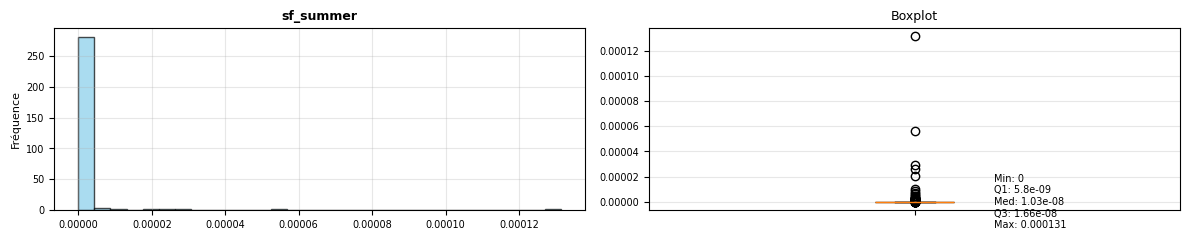

Outliers for sf_summer (59 cities):
Glasgow (3.29e-08), Saint Petersburg (3.56e-08), Ferrara (4.73e-08), Plovdiv (4.78e-08), Ploieşti (6.31e-08), Sofia (6.69e-08), Valladolid (6.72e-08), Donostia / San Sebastián (7.07e-08), Oradea (7.61e-08), Kiev (8.45e-08), Salamanca (8.46e-08), Venezia (8.96e-08), Oslo (9.42e-08), Mestre (1.09e-07), Padova (1.2e-07), Livorno (1.21e-07), Zagreb (1.23e-07), Skopje (1.26e-07), Bilbao (1.28e-07), Lucca (1.36e-07), Santander (1.85e-07), Pisa (2.37e-07), Burgos (2.37e-07), Brescia (2.87e-07), Braşov (3.01e-07), Bergen (3.39e-07), Espoo (3.42e-07), Oulu (4.31e-07), Toledo (4.61e-07), Cluj-Napoca (4.98e-07), La Spezia (5.97e-07), Oviedo (6.39e-07), Moscow (6.91e-07), Graz (9.21e-07), München (1.02e-06), Pamplona (1.15e-06), Gijón (1.24e-06), Verona (1.38e-06), Split (1.54e-06), Sarajevo (1.87e-06), Madrid (2.03e-06), Milan (2.05e-06), Ljubljana (2.17e-06), Bergamo (2.37e-06), Alcalá de Henares (2.75e-06), Freiburg (2.85e-06), Grenoble (2.91e-06), Reykjavík 

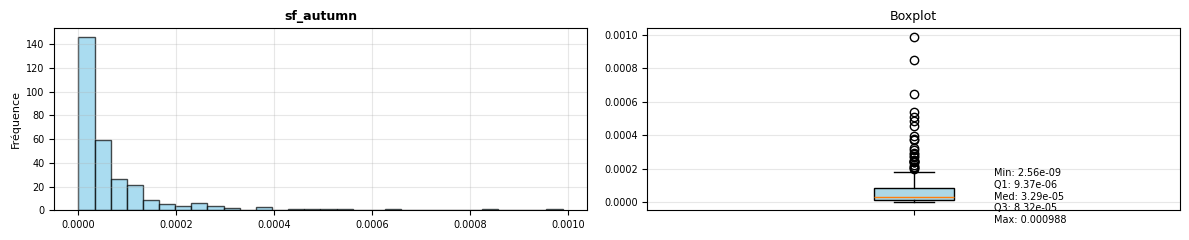

Outliers for sf_autumn (27 cities):
Ploieşti (0.000197), Helsinki (0.0002), Sochi (0.000207), Sofia (0.00021), Espoo (0.000221), Sarajevo (0.000239), Turin (0.000241), Zürich (0.000241), Tallinn (0.000242), München (0.000248), Tampere (0.000253), Braşov (0.000271), Graz (0.000272), Saint Petersburg (0.000284), Oslo (0.000291), Moscow (0.00031), Grenoble (0.000324), Ljubljana (0.00037), Yaroslavl' (0.000376), Oulu (0.000395), Lausanne (0.000451), Reykjavík (0.000486), Bern (0.000508), Salzburg (0.000538), Como (0.000644), Bergen (0.000851), Innsbruck (0.000988)



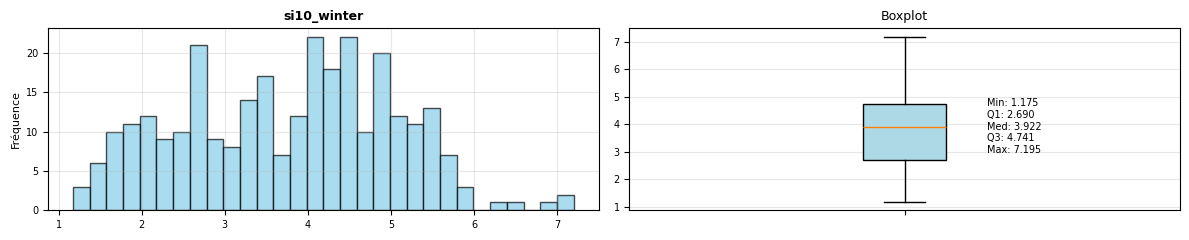

No outliers for si10_winter



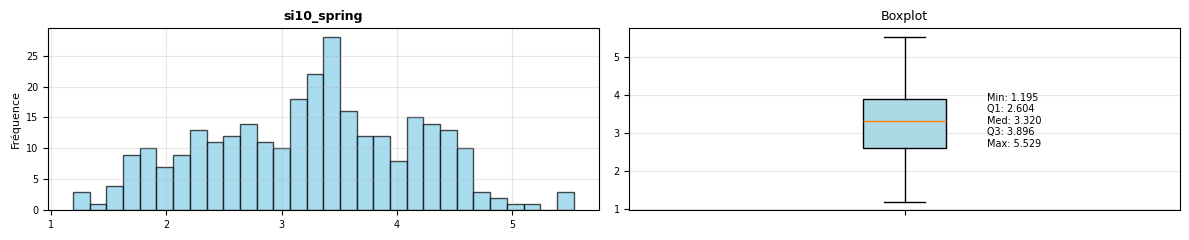

No outliers for si10_spring



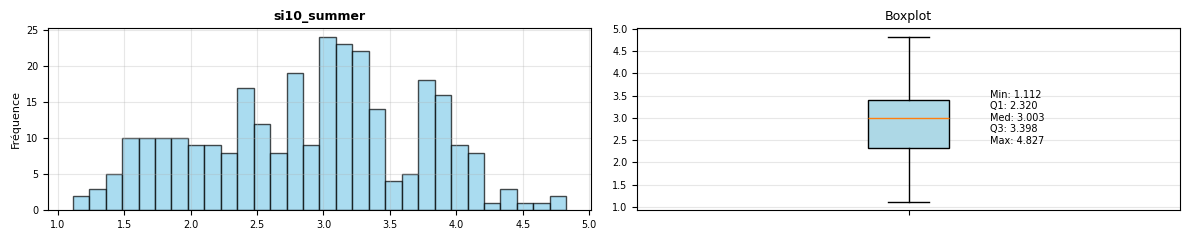

No outliers for si10_summer



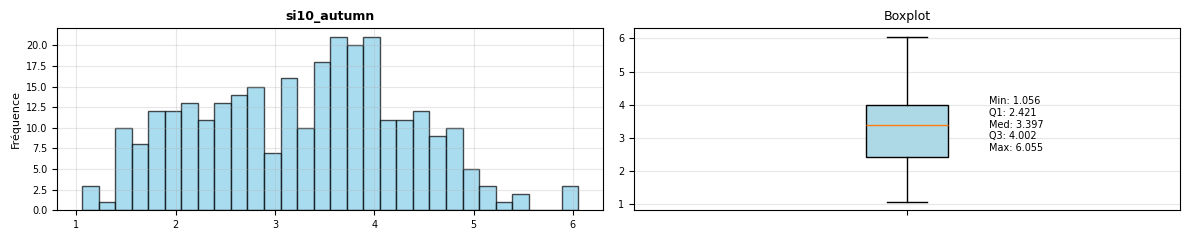

No outliers for si10_autumn



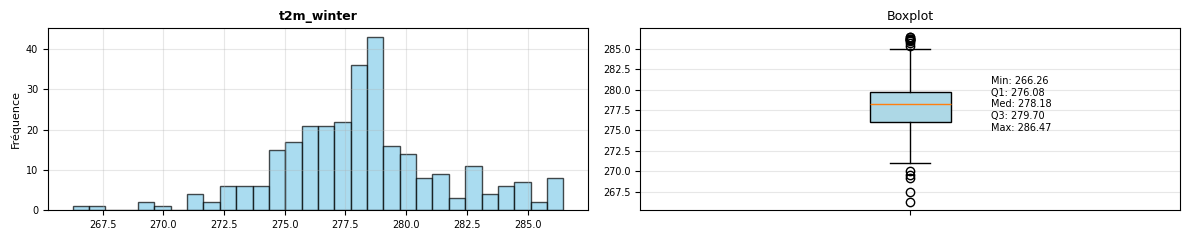

Outliers for t2m_winter (15 cities):
Oulu (266.26), Yaroslavl' (267.54), Tampere (269.18), Moscow (269.53), Saint Petersburg (270.06), Roquetas de Mar (285.37), Elche (285.69), Palma (285.94), Lisbon (286.09), Marbella (286.10), Marsala (286.16), Cartagena (286.22), Jerez de la Frontera (286.23), Siracusa (286.45), Setúbal (286.47)



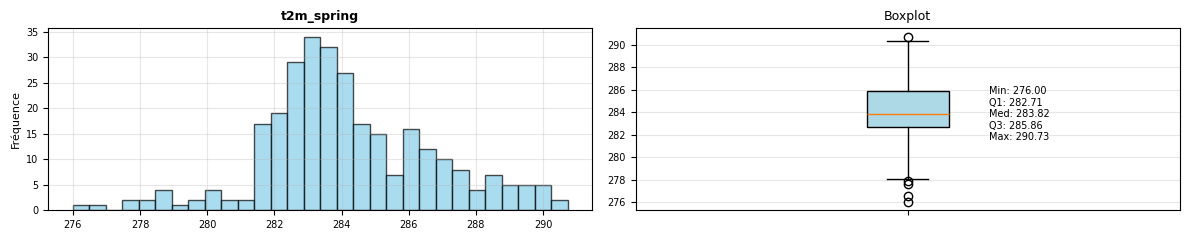

Outliers for t2m_spring (5 cities):
Oulu (276.00), Reykjavík (276.49), Innsbruck (277.56), Helsinki (277.85), Jerez de la Frontera (290.73)



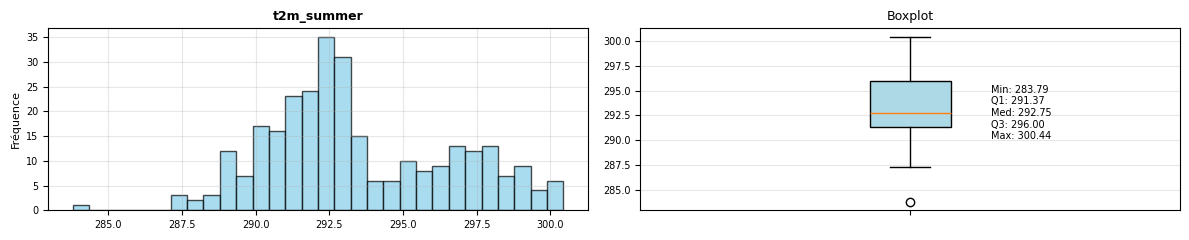

Outliers for t2m_summer (1 cities):
Reykjavík (283.79)



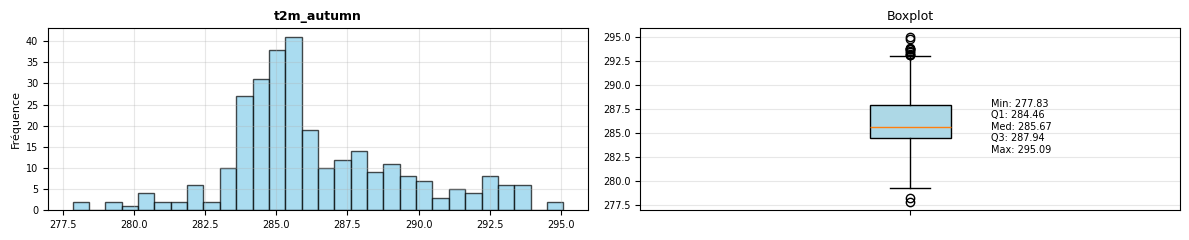

Outliers for t2m_autumn (13 cities):
Oulu (277.83), Reykjavík (278.23), Sevilla (293.17), Roquetas de Mar (293.19), Catania (293.33), Messina (293.51), Palermo (293.61), Elche (293.76), Jerez de la Frontera (293.80), Cartagena (293.83), Palma (293.87), Marsala (294.81), Siracusa (295.09)



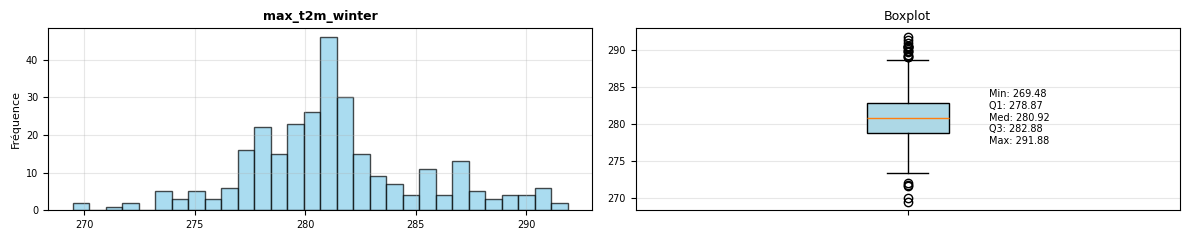

Outliers for max_t2m_winter (21 cities):
Oulu (269.48), Yaroslavl' (270.07), Moscow (271.70), Tampere (271.73), Saint Petersburg (271.99), Marsala (289.08), Córdoba (289.12), Siracusa (289.29), Coimbra (289.35), Cartagena (289.83), Setúbal (289.93), Valencia (289.93), Lisbon (290.21), Alicante (290.42), Marbella (290.44), Málaga (290.45), Murcia (290.57), Sevilla (290.61), Roquetas de Mar (291.02), Jerez de la Frontera (291.37), Elche (291.88)



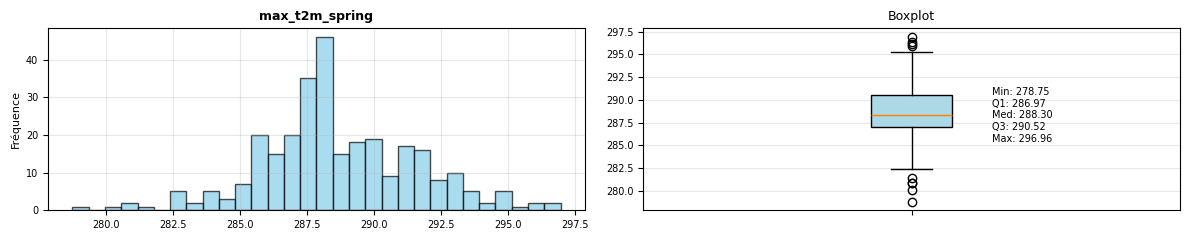

Outliers for max_t2m_spring (9 cities):
Reykjavík (278.75), Oulu (280.06), Helsinki (280.87), Tallinn (280.88), Innsbruck (281.37), Elche (295.97), Jerez de la Frontera (296.11), Córdoba (296.37), Sevilla (296.96)



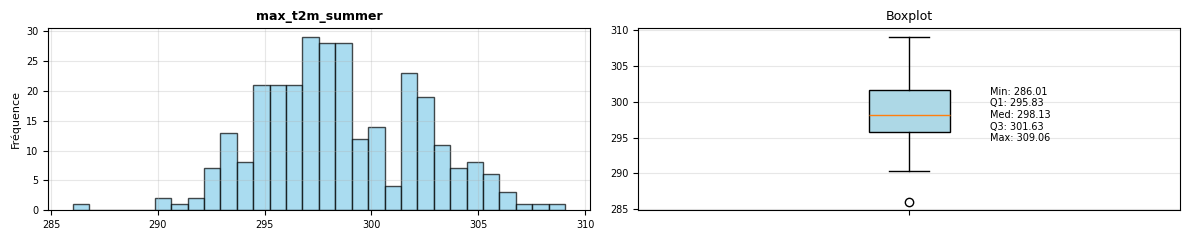

Outliers for max_t2m_summer (1 cities):
Reykjavík (286.01)



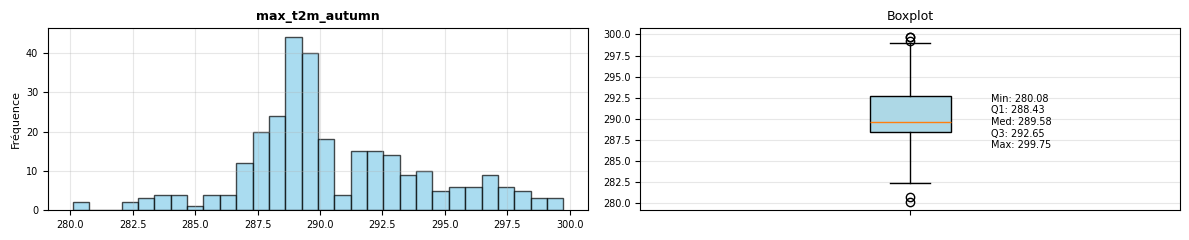

Outliers for max_t2m_autumn (5 cities):
Reykjavík (280.08), Oulu (280.66), Jerez de la Frontera (299.19), Elche (299.64), Sevilla (299.75)



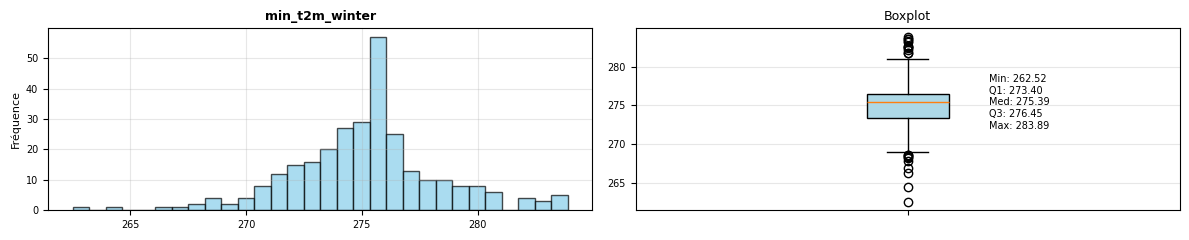

Outliers for min_t2m_winter (22 cities):
Oulu (262.52), Yaroslavl' (264.51), Tampere (266.23), Moscow (266.89), Saint Petersburg (267.79), Espoo (268.15), Innsbruck (268.32), Braşov (268.46), Vantaa (268.54), Oslo (268.59), Jerez de la Frontera (281.80), Toulon (281.81), Catania (282.15), Marbella (282.36), Palermo (282.52), Messina (282.57), Lisbon (282.65), Marsala (283.24), Cartagena (283.31), Setúbal (283.54), Palma (283.58), Siracusa (283.89)



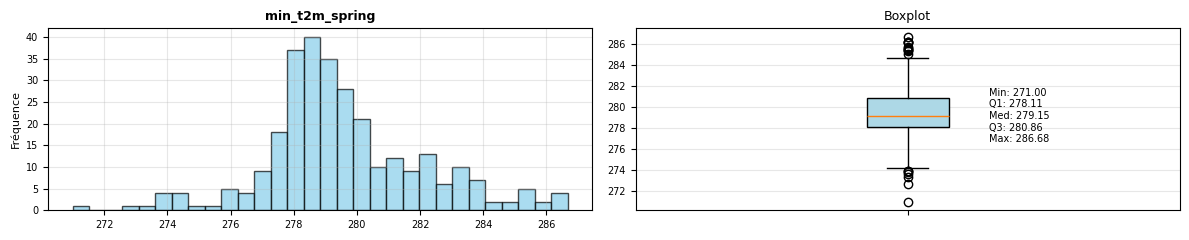

Outliers for min_t2m_spring (19 cities):
Oulu (271.00), Tampere (272.69), Espoo (273.40), Innsbruck (273.69), Oslo (273.81), Vantaa (273.92), Reykjavík (273.92), Toulon (284.99), Catania (285.28), Palermo (285.38), Jerez de la Frontera (285.40), Marbella (285.47), Messina (285.60), Lisbon (285.71), Marsala (286.06), Palma (286.16), Cartagena (286.19), Setúbal (286.20), Siracusa (286.68)



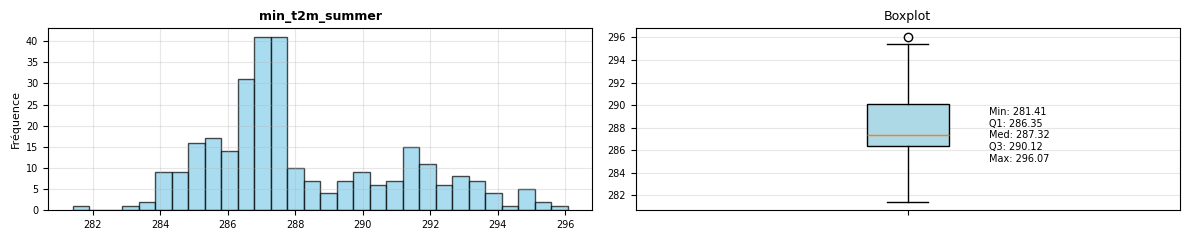

Outliers for min_t2m_summer (1 cities):
Siracusa (296.07)



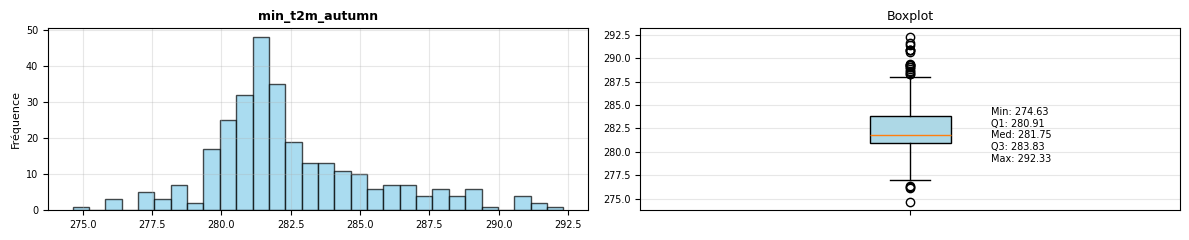

Outliers for min_t2m_autumn (22 cities):
Oulu (274.63), Tampere (276.13), Reykjavík (276.28), Yaroslavl' (276.39), Taranto (288.30), Salerno (288.31), Roquetas de Mar (288.57), Elche (288.62), Lisbon (288.90), Jerez de la Frontera (289.10), Lecce (289.12), Marbella (289.28), Cagliari (289.32), Toulon (289.32), Setúbal (289.40), Catania (290.70), Messina (290.87), Palermo (290.91), Cartagena (290.93), Palma (291.42), Marsala (291.60), Siracusa (292.33)



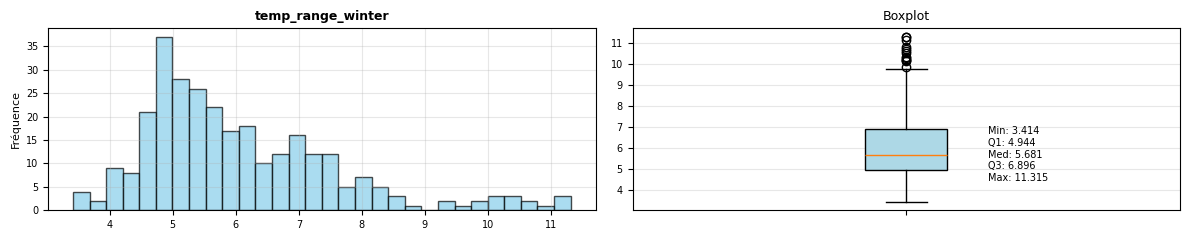

Outliers for temp_range_winter (13 cities):
Madrid (9.866), Roquetas de Mar (10.141), Alcalá de Henares (10.201), Málaga (10.208), Toledo (10.284), Almería (10.331), Granada (10.514), Valencia (10.627), Sevilla (10.702), Alicante (10.818), Murcia (11.172), Córdoba (11.303), Elche (11.315)



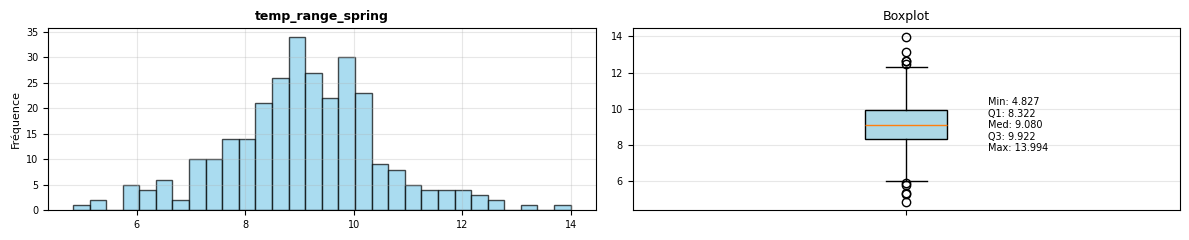

Outliers for temp_range_spring (10 cities):
Reykjavík (4.827), Palma (5.292), Toulon (5.317), Aberdeen (5.751), Donostia / San Sebastián (5.900), Toledo (12.461), Salamanca (12.627), Zaragoza (12.634), Sevilla (13.129), Córdoba (13.994)



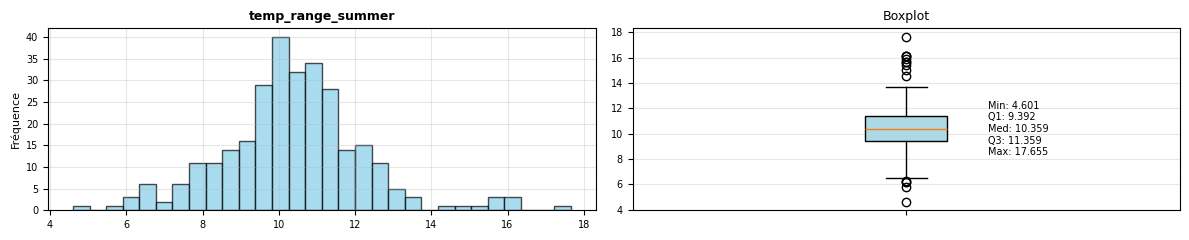

Outliers for temp_range_summer (15 cities):
Reykjavík (4.601), Palma (5.759), Aberdeen (6.173), Toulon (6.220), Tallinn (6.239), Burgos (14.579), Granada (14.988), Madrid (15.453), Valladolid (15.653), Toledo (15.676), Zaragoza (15.869), Sevilla (16.098), Alcalá de Henares (16.101), Salamanca (16.108), Córdoba (17.655)



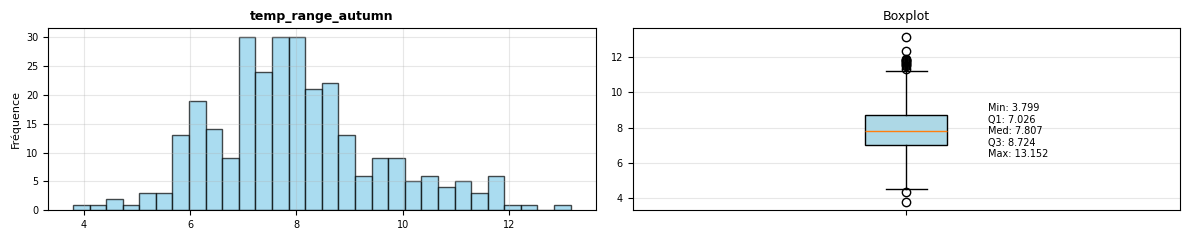

Outliers for temp_range_autumn (14 cities):
Reykjavík (3.799), Tallinn (4.344), Madrid (11.313), Braşov (11.483), Ploieşti (11.521), Valladolid (11.602), Bucharest (11.663), Zaragoza (11.704), Granada (11.748), Toledo (11.805), Alcalá de Henares (11.809), Salamanca (11.906), Sevilla (12.347), Córdoba (13.152)


--- Summary for dataset: 2021-2050_ssp585 ---

First 5 rows:
                city   latitude  longitude   hot_days  hot_days_consec  \
0             Aachen  50.776642    6.08342  15.900000         5.733333   
1           Aberdeen  57.143688   -2.09814   0.000000         0.000000   
2    Aix-en-Provence  43.528301    5.44973  37.466667        17.800000   
3  Alcalá de Henares  40.482052   -3.35996  88.800000        48.300000   
4           Alicante  38.345169   -0.48149  94.233333        58.033333   

   tp_winter  tp_spring  tp_summer  tp_autumn  sf_winter  ...  max_t2m_summer  \
0   0.003041   0.002495   0.002484   0.002483   0.000325  ...       297.89203   
1   0.002545   0.00

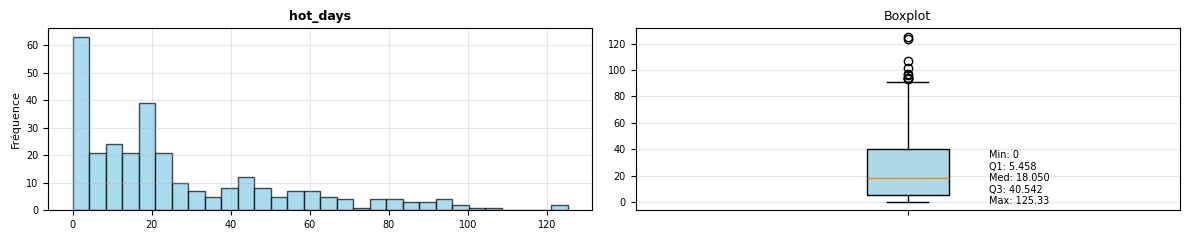

Outliers for hot_days (10 cities):
Athens (93.533), Murcia (93.600), Jerez de la Frontera (94.200), Alicante (94.233), Thessaloníki (96.367), Piraeus (96.833), Toledo (101.53), Elche (106.80), Sevilla (123.17), Córdoba (125.33)



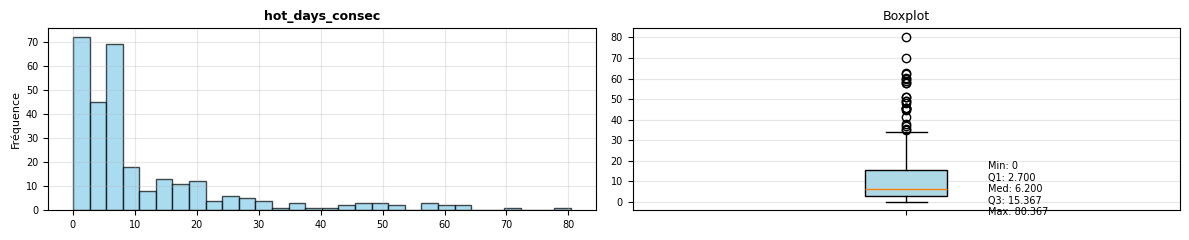

Outliers for hot_days_consec (24 cities):
Siracusa (35.067), Bari (35.700), Zaragoza (36.700), Rome (37.833), Taranto (41.133), Jerez de la Frontera (44.633), Roquetas de Mar (45.267), Madrid (45.667), Lecce (45.667), Almería (45.900), Alcalá de Henares (48.300), Málaga (49.100), Valencia (49.267), Marsala (51.167), Granada (51.233), Athens (57.733), Alicante (58.033), Murcia (58.700), Toledo (59.667), Thessaloníki (60.033), Piraeus (62.200), Elche (62.633), Sevilla (70.167), Córdoba (80.367)



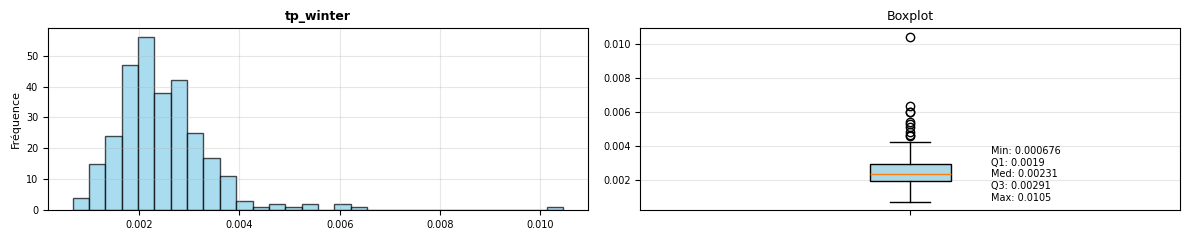

Outliers for tp_winter (10 cities):
Donostia / San Sebastián (0.00457), Porto (0.00462), Lausanne (0.0048), Braga (0.00508), Santiago de Compostela (0.00531), Glasgow (0.00543), Sochi (0.006), Vigo (0.00602), Reykjavík (0.00634), Bergen (0.0105)



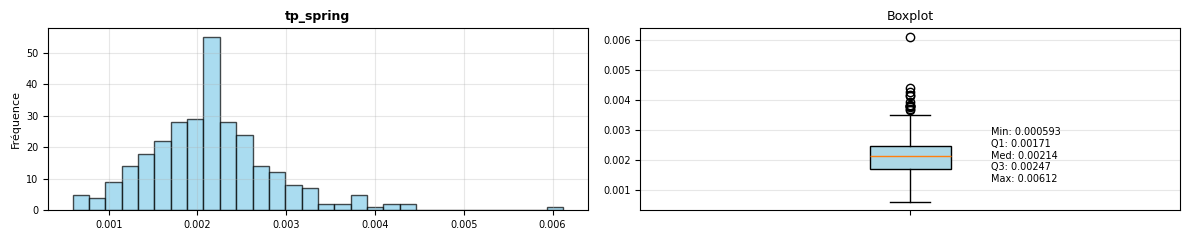

Outliers for tp_spring (13 cities):
Santiago de Compostela (0.00365), Pamplona (0.00369), Ljubljana (0.00377), Glasgow (0.00382), Reykjavík (0.00382), Bern (0.00382), Donostia / San Sebastián (0.00385), Vigo (0.00393), Sochi (0.00413), Salzburg (0.00417), Lausanne (0.00428), Como (0.0044), Bergen (0.00612)



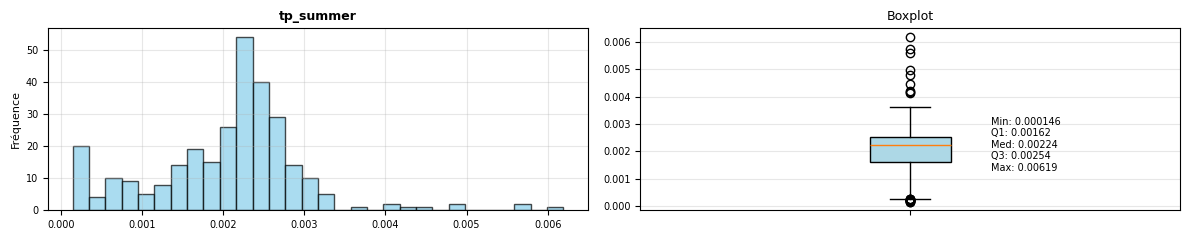

Outliers for tp_summer (21 cities):
Marsala (0.000146), Siracusa (0.000152), Málaga (0.000185), Jerez de la Frontera (0.000191), Marbella (0.000199), Cartagena (0.000217), Athens (0.000224), Roquetas de Mar (0.000231), Sevilla (0.000234), Cagliari (0.000241), Catania (0.000247), Piraeus (0.000248), Bern (0.00413), Zürich (0.00415), Graz (0.00419), Ljubljana (0.00444), Como (0.00479), München (0.00496), Bergen (0.00561), Innsbruck (0.00576), Salzburg (0.00619)



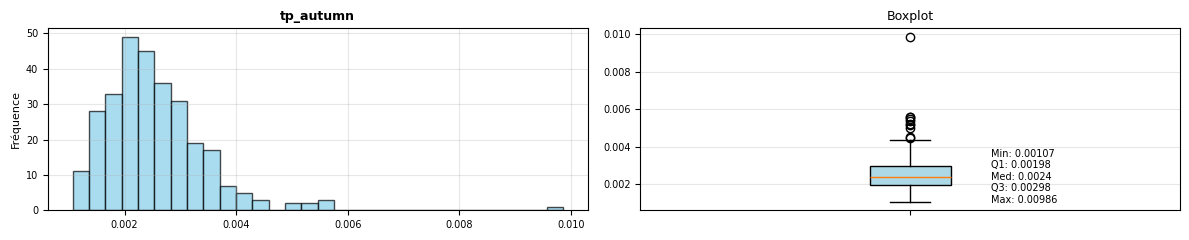

Outliers for tp_autumn (10 cities):
La Spezia (0.00448), Trieste (0.00454), Ljubljana (0.00502), Como (0.00514), Reykjavík (0.00521), Rome (0.00536), Glasgow (0.00548), Vigo (0.00556), Sochi (0.00559), Bergen (0.00986)



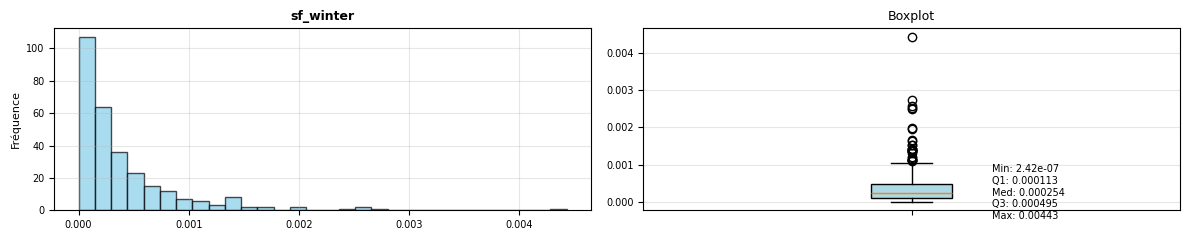

Outliers for sf_winter (27 cities):
Turku (0.0011), Saint Petersburg (0.00111), Ploieşti (0.00112), München (0.00112), Sarajevo (0.00112), Ljubljana (0.00118), Sofia (0.0012), Braşov (0.00132), Como (0.00135), Grenoble (0.00137), Yaroslavl' (0.00138), Oulu (0.00138), Tampere (0.00139), Vantaa (0.00141), Moscow (0.00141), Zürich (0.00143), Helsinki (0.00152), Tallinn (0.00152), Bern (0.00163), Espoo (0.00165), Lausanne (0.00195), Oslo (0.00199), Salzburg (0.0025), Sochi (0.00253), Innsbruck (0.00258), Reykjavík (0.00272), Bergen (0.00443)



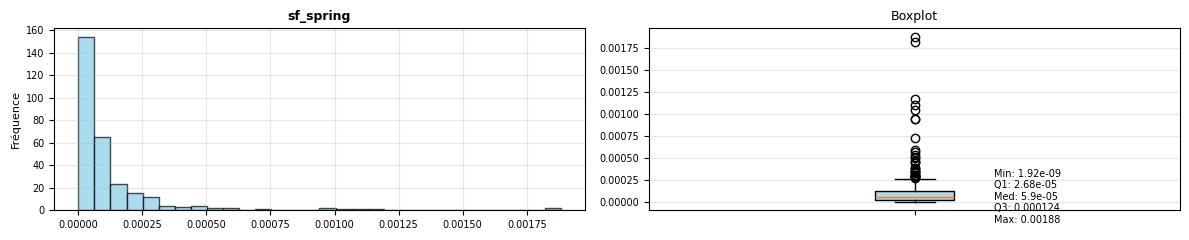

Outliers for sf_spring (31 cities):
Saint Petersburg (0.000269), Tallinn (0.000281), Ploieşti (0.00029), Plovdiv (0.000293), Moscow (0.000298), Yaroslavl' (0.000299), Vantaa (0.000307), Helsinki (0.000308), Graz (0.000325), Kraków (0.000343), Ljubljana (0.000347), Glasgow (0.000351), Espoo (0.000379), Tampere (0.000389), Sarajevo (0.00039), Turin (0.000441), Sofia (0.000453), München (0.000467), Oulu (0.000501), Grenoble (0.000516), Braşov (0.000539), Zürich (0.000568), Sochi (0.000594), Oslo (0.000724), Bern (0.000943), Lausanne (0.000945), Reykjavík (0.00105), Como (0.0011), Salzburg (0.00118), Bergen (0.00182), Innsbruck (0.00188)



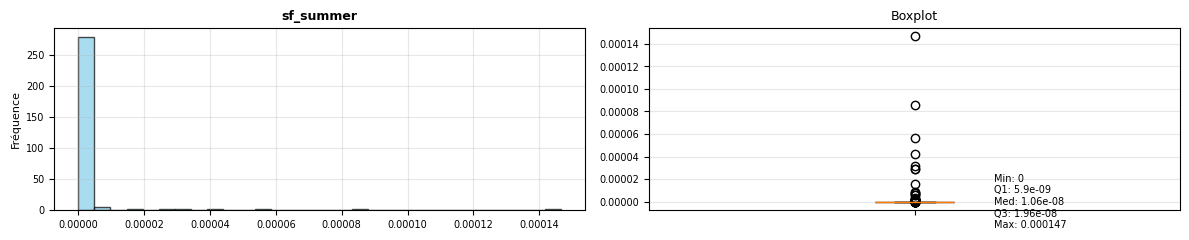

Outliers for sf_summer (60 cities):
Aberdeen (4.09e-08), Skopje (4.34e-08), Saint Petersburg (4.44e-08), Prato (4.52e-08), Bratislava (4.83e-08), Valladolid (5.33e-08), Espoo (5.33e-08), Livorno (6.05e-08), Sofia (6.31e-08), Avignon (6.43e-08), Bologna (6.89e-08), Alcalá de Henares (6.91e-08), Modena (7.93e-08), Oslo (7.93e-08), Madrid (8.22e-08), Burgos (8.39e-08), Ferrara (8.91e-08), Cluj-Napoca (9.24e-08), Lucca (9.94e-08), Parma (1.11e-07), Pisa (1.15e-07), Saint-Étienne (1.77e-07), Split (2.02e-07), Salamanca (3.14e-07), Sarajevo (3.29e-07), Santander (3.42e-07), Zaragoza (4.95e-07), Oulu (4.98e-07), Donostia / San Sebastián (5.16e-07), Bergen (6.55e-07), Oviedo (7.17e-07), Zagreb (7.29e-07), La Spezia (7.35e-07), Moscow (7.75e-07), Reykjavík (9.08e-07), Venezia (9.2e-07), Padova (1.05e-06), Gijón (1.08e-06), München (1.2e-06), Pamplona (1.58e-06), Mestre (1.71e-06), Grenoble (1.75e-06), Verona (1.83e-06), Brescia (1.95e-06), Graz (2.36e-06), Ljubljana (2.81e-06), Toulouse (3.27e-

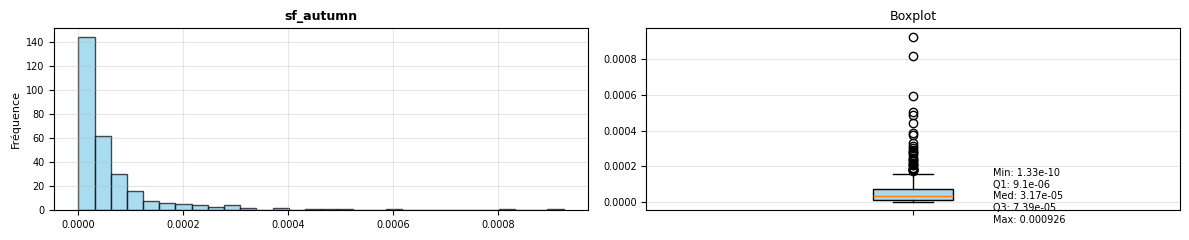

Outliers for sf_autumn (31 cities):
Kiev (0.000175), Ploieşti (0.000178), Zürich (0.00018), Sofia (0.000182), München (0.000182), Tampere (0.000192), Verona (0.000193), Brescia (0.000206), Helsinki (0.000207), Vantaa (0.00021), Graz (0.000218), Tallinn (0.00023), Turin (0.000234), Ljubljana (0.000243), Espoo (0.000248), Sarajevo (0.000263), Grenoble (0.000274), Oslo (0.000278), Sochi (0.000282), Braşov (0.00029), Moscow (0.000303), Saint Petersburg (0.000312), Oulu (0.000328), Yaroslavl' (0.000378), Lausanne (0.000387), Bern (0.000445), Salzburg (0.000487), Reykjavík (0.000502), Como (0.000594), Bergen (0.000816), Innsbruck (0.000926)



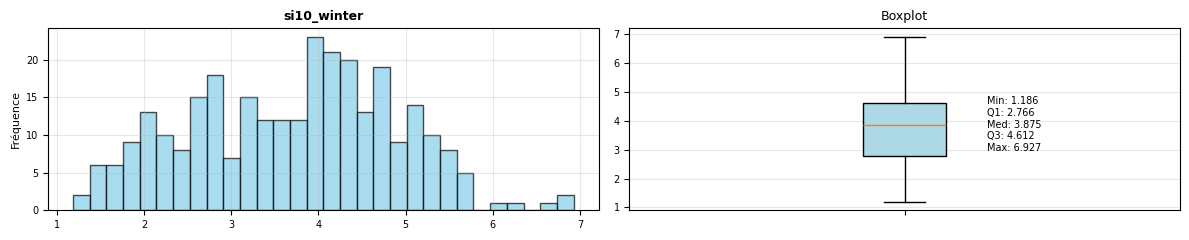

No outliers for si10_winter



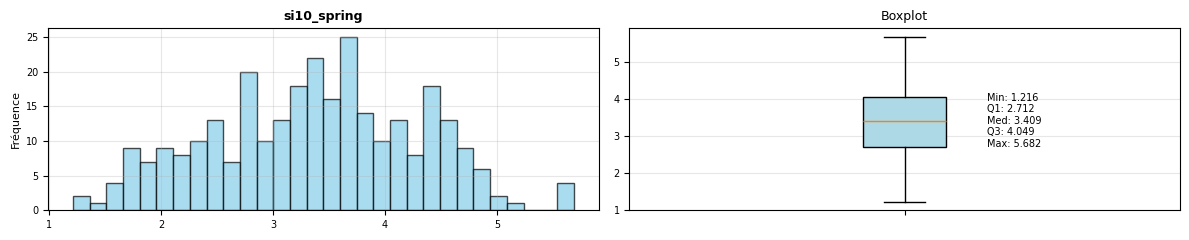

No outliers for si10_spring



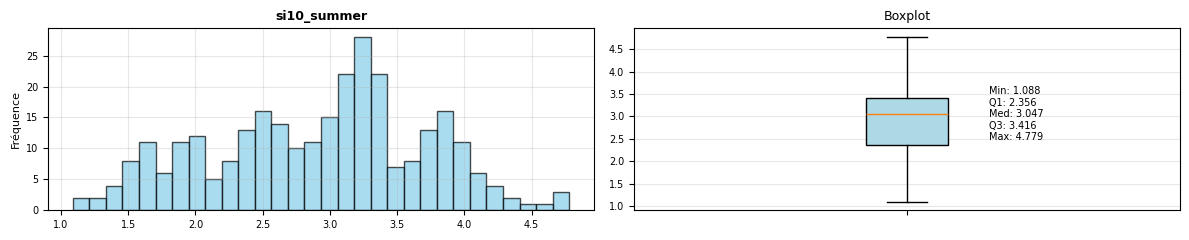

No outliers for si10_summer



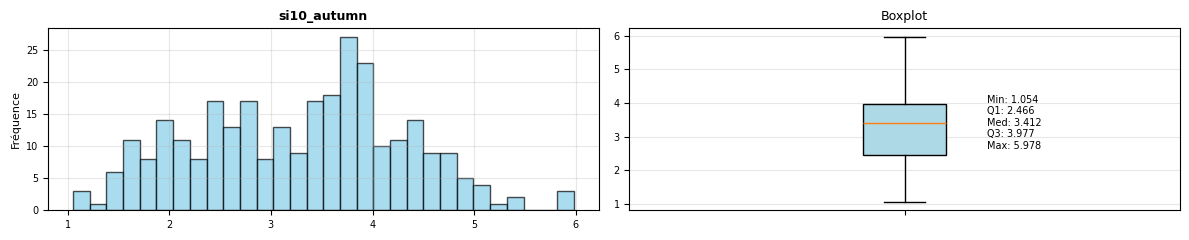

No outliers for si10_autumn



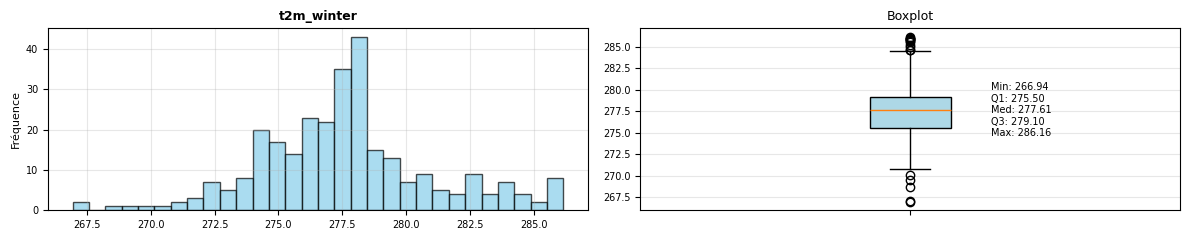

Outliers for t2m_winter (17 cities):
Yaroslavl' (266.94), Oulu (267.08), Moscow (268.71), Tampere (269.50), Saint Petersburg (270.05), Palermo (284.58), Messina (284.63), Roquetas de Mar (284.93), Elche (285.23), Palma (285.52), Lisbon (285.63), Marbella (285.73), Marsala (285.83), Cartagena (285.85), Jerez de la Frontera (285.87), Setúbal (286.03), Siracusa (286.16)



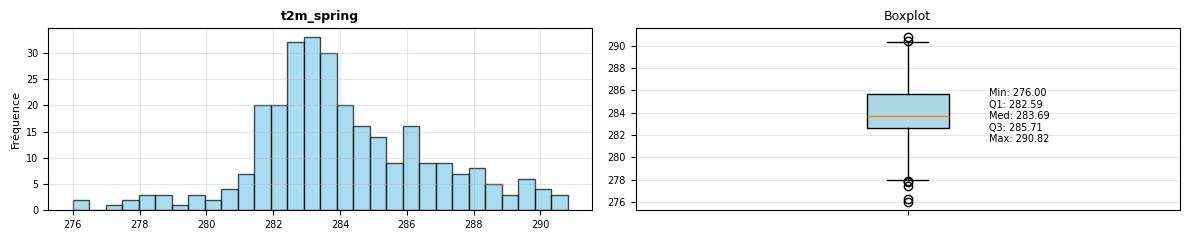

Outliers for t2m_spring (7 cities):
Oulu (276.00), Reykjavík (276.28), Innsbruck (277.44), Helsinki (277.77), Tampere (277.91), Sevilla (290.42), Jerez de la Frontera (290.82)



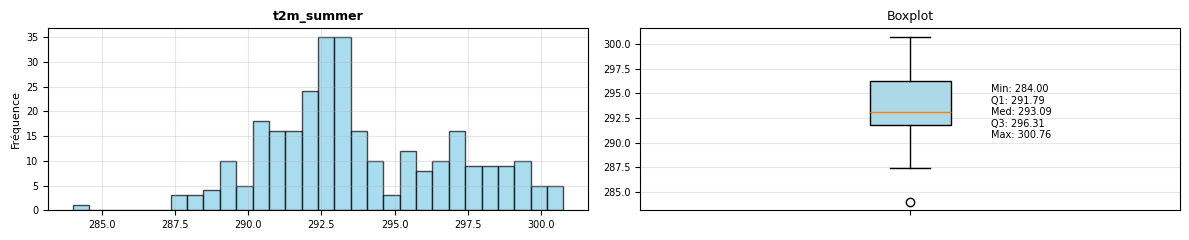

Outliers for t2m_summer (1 cities):
Reykjavík (284.00)



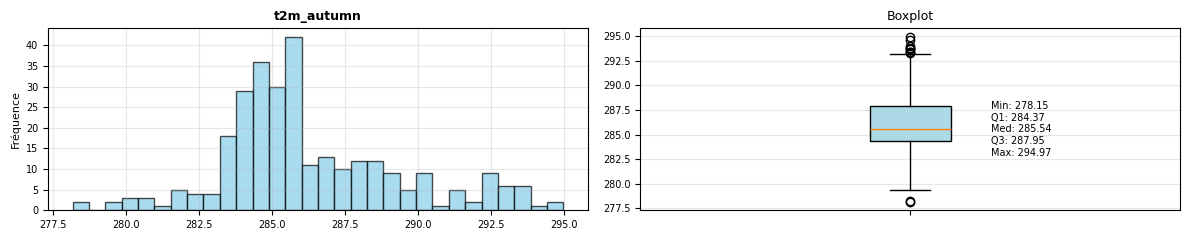

Outliers for t2m_autumn (11 cities):
Oulu (278.15), Reykjavík (278.25), Sevilla (293.33), Messina (293.36), Palermo (293.40), Palma (293.71), Elche (293.71), Cartagena (293.78), Jerez de la Frontera (293.97), Marsala (294.62), Siracusa (294.97)



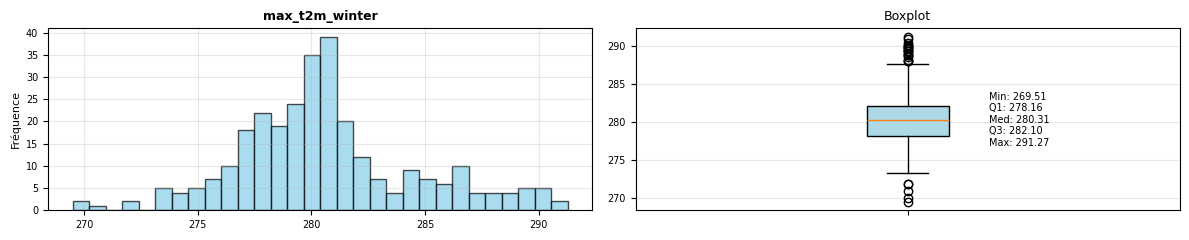

Outliers for max_t2m_winter (24 cities):
Yaroslavl' (269.51), Oulu (270.01), Moscow (270.95), Saint Petersburg (271.91), Tampere (271.92), Palma (288.02), Porto (288.04), Almería (288.15), Córdoba (288.64), Marsala (288.80), Coimbra (288.87), Siracusa (288.97), Valencia (289.32), Cartagena (289.37), Setúbal (289.39), Lisbon (289.66), Alicante (289.81), Málaga (289.90), Marbella (289.96), Murcia (289.99), Sevilla (290.13), Roquetas de Mar (290.43), Jerez de la Frontera (290.89), Elche (291.27)



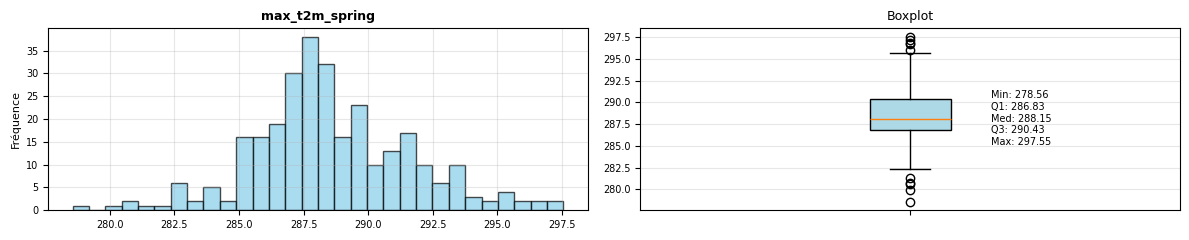

Outliers for max_t2m_spring (10 cities):
Reykjavík (278.56), Oulu (279.89), Helsinki (280.68), Tallinn (280.70), Innsbruck (281.34), Málaga (296.05), Jerez de la Frontera (296.66), Elche (296.83), Córdoba (297.22), Sevilla (297.55)



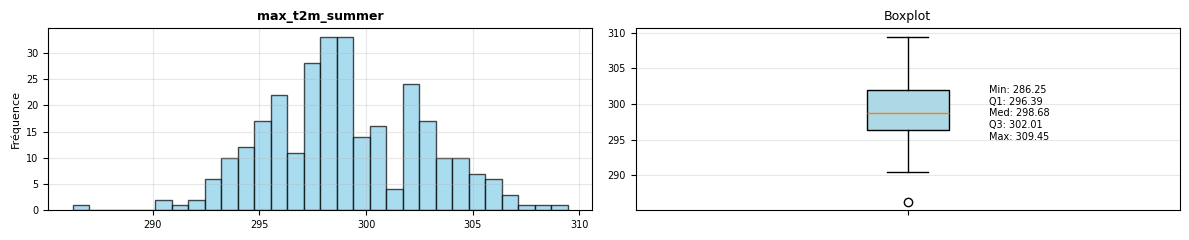

Outliers for max_t2m_summer (1 cities):
Reykjavík (286.25)



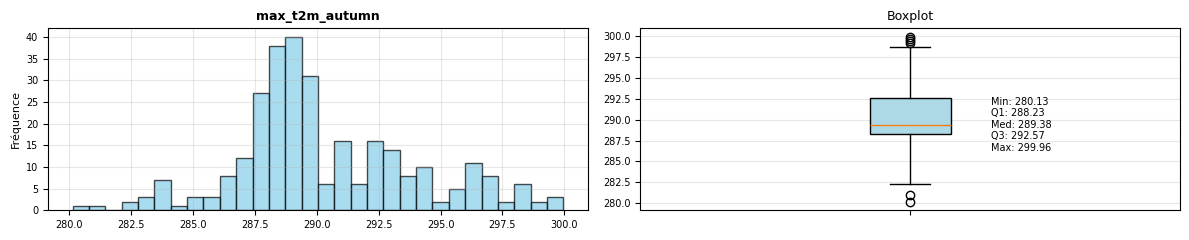

Outliers for max_t2m_autumn (6 cities):
Reykjavík (280.13), Oulu (280.91), Córdoba (299.14), Jerez de la Frontera (299.42), Elche (299.63), Sevilla (299.96)



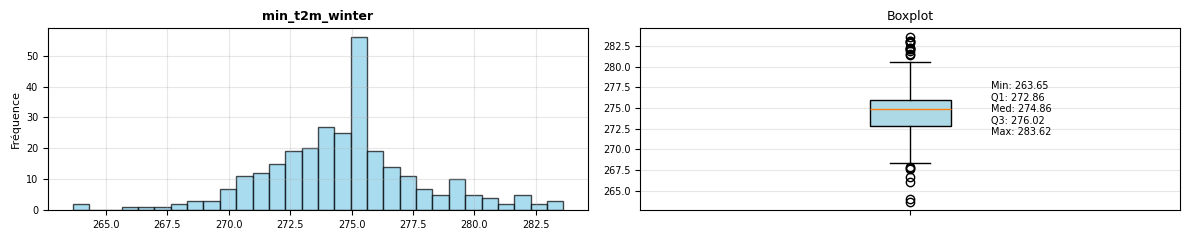

Outliers for min_t2m_winter (19 cities):
Oulu (263.65), Yaroslavl' (263.97), Moscow (266.03), Tampere (266.68), Braşov (267.62), Innsbruck (267.71), Saint Petersburg (267.91), Toulon (281.38), Jerez de la Frontera (281.48), Catania (281.85), Marbella (282.07), Palermo (282.09), Lisbon (282.21), Messina (282.23), Marsala (282.84), Cartagena (282.95), Palma (283.10), Setúbal (283.13), Siracusa (283.62)



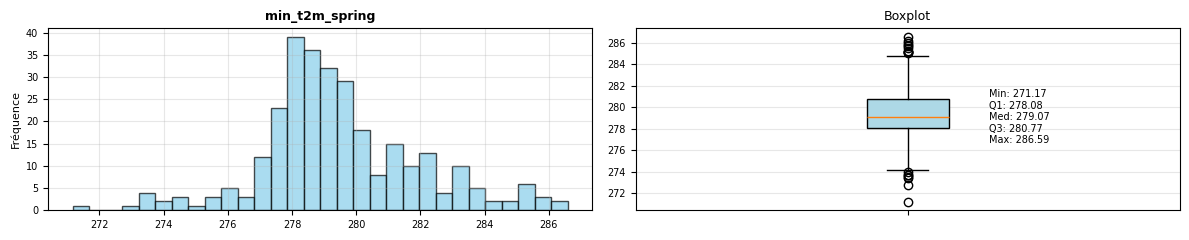

Outliers for min_t2m_spring (18 cities):
Oulu (271.17), Tampere (272.73), Innsbruck (273.45), Espoo (273.48), Reykjavík (273.69), Oslo (273.70), Vantaa (273.99), Jerez de la Frontera (285.05), Palermo (285.17), Catania (285.18), Lisbon (285.18), Marbella (285.23), Messina (285.49), Setúbal (285.68), Marsala (285.84), Palma (285.97), Cartagena (286.19), Siracusa (286.59)



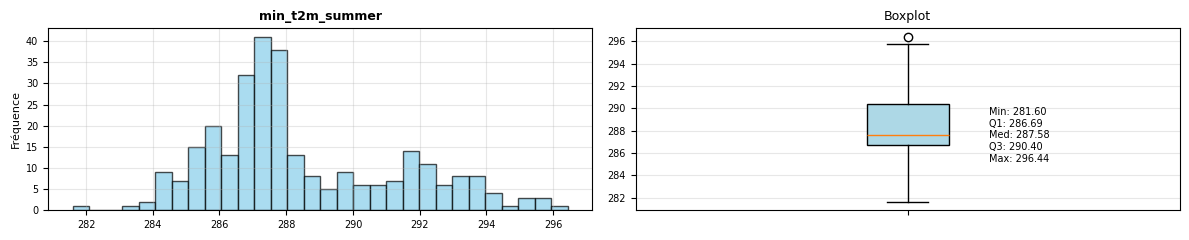

Outliers for min_t2m_summer (1 cities):
Siracusa (296.44)



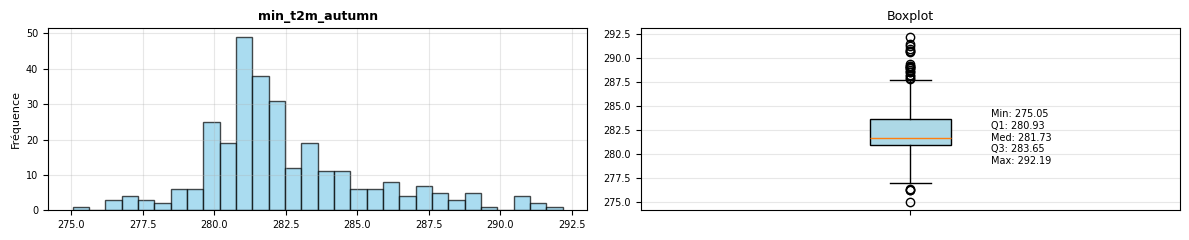

Outliers for min_t2m_autumn (24 cities):
Oulu (275.05), Reykjavík (276.27), Tampere (276.28), Yaroslavl' (276.38), Málaga (287.81), Athens (287.94), Taranto (288.13), Salerno (288.17), Elche (288.54), Roquetas de Mar (288.56), Lisbon (288.70), Lecce (288.93), Toulon (288.98), Cagliari (289.05), Jerez de la Frontera (289.18), Setúbal (289.19), Marbella (289.39), Catania (290.55), Messina (290.69), Palermo (290.70), Cartagena (290.86), Palma (291.24), Marsala (291.40), Siracusa (292.19)



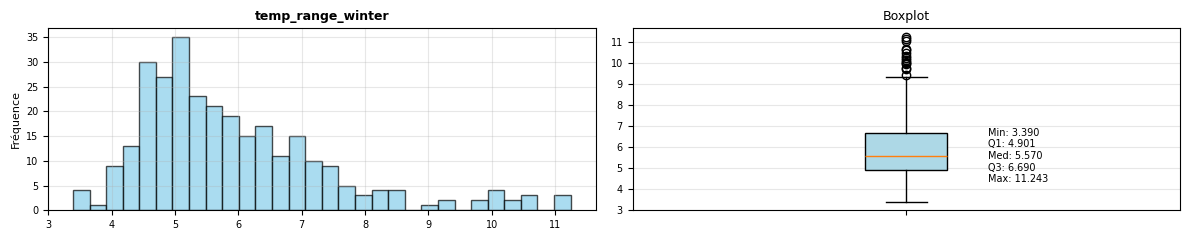

Outliers for temp_range_winter (15 cities):
Jerez de la Frontera (9.409), Madrid (9.721), Zaragoza (9.763), Roquetas de Mar (9.957), Málaga (9.993), Alcalá de Henares (10.035), Almería (10.150), Toledo (10.223), Granada (10.338), Valencia (10.462), Sevilla (10.608), Alicante (10.643), Murcia (11.011), Elche (11.137), Córdoba (11.243)



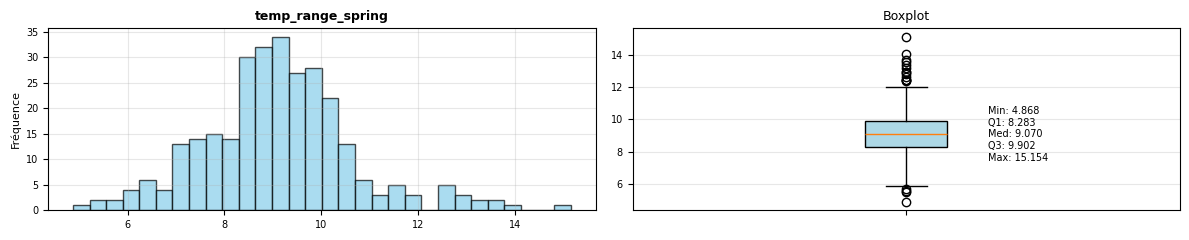

Outliers for temp_range_spring (18 cities):
Reykjavík (4.868), Toulon (5.507), Palma (5.524), Aberdeen (5.685), Valencia (12.414), Alicante (12.429), Málaga (12.444), Murcia (12.476), Elche (12.669), Valladolid (12.813), Madrid (12.930), Granada (12.963), Salamanca (13.201), Alcalá de Henares (13.404), Toledo (13.571), Zaragoza (13.707), Sevilla (14.100), Córdoba (15.154)



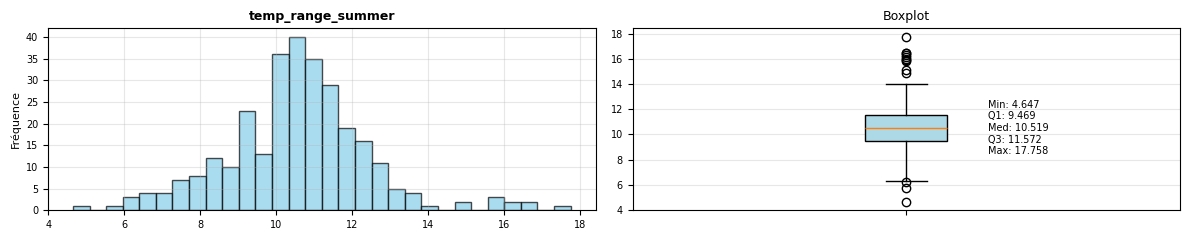

Outliers for temp_range_summer (13 cities):
Reykjavík (4.647), Palma (5.748), Toulon (6.236), Burgos (14.869), Granada (15.084), Madrid (15.844), Toledo (15.918), Valladolid (15.986), Zaragoza (16.137), Sevilla (16.308), Salamanca (16.452), Alcalá de Henares (16.490), Córdoba (17.758)



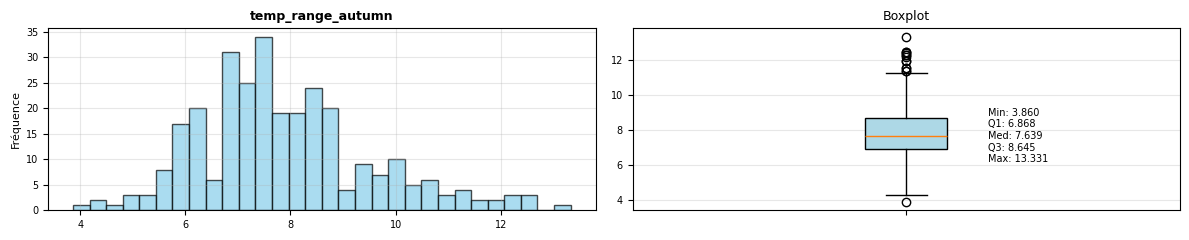

Outliers for temp_range_autumn (14 cities):
Reykjavík (3.860), Braşov (11.336), Ploieşti (11.365), Bucharest (11.519), Burgos (11.551), Madrid (11.918), Granada (11.930), Valladolid (12.170), Toledo (12.254), Zaragoza (12.259), Alcalá de Henares (12.420), Salamanca (12.453), Sevilla (12.473), Córdoba (13.331)



In [5]:
for key, df in datasets.items():
    print(f"\n--- Summary for dataset: {key} ---\n")
    summarize_dataset(df)
    
    features = df.select_dtypes(include=[np.number]).columns.tolist()
    plot_feature_distributions(df, features)